# Deep Learning for Natural Language Processing

# Homework 2 - Spring 2025

## Angelos Dorotheos Chatzopoulos
## 7115112400027

### Python package PIP installs

In [ ]:
%pip install contractions

In [ ]:
!wget https://figshare.com/ndownloader/files/10798046 -O GoogleNews-vectors-negative300.bin

### Python Packages Imports

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
from wordcloud import WordCloud
import re

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
import contractions
import string

import warnings
import random
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from gensim.models import KeyedVectors

import optuna

### Setting a seed for `numpy`, `os`, `random` and `pytorch` packages

In [3]:
seed = 42

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [4]:
torch.cuda.is_available()

True

## Exploratory Data Analysis (EDA)

### Function that plots a pie chart of the percentage of positive and negative labels of datasets

In [5]:
def plot_pie_chart(counts, title):
    counts = pd.Series(counts)
    counts.plot(kind='pie', autopct='%1.2f%%', figsize=(8, 8), colors=['darkorange', 'royalblue'])
    plt.title(title)
    plt.ylabel('Labels Distribution')
    plt.show()

### Function that plots a histogram that shows the distribution of tweets length across the dataset

In [6]:
def plot_histogram(data, x_label, y_label, title):
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=list(np.arange(0, 40, 5)), edgecolor='black', color='royalblue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(0, 50)
    plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1)
    _, max_ylim = plt.ylim()
    plt.text(data.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f}'.format(data.mean()))
    plt.tight_layout()
    plt.show()

### Function that plots a wordcloud with the most common words of the dataset

In [7]:
def create_wordcloud(text):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, height=400, background_color='white', random_state=42).generate(all_text)
    plt.figure(figsize=(12, 10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

### Function that plots a bar graph. Used for min-max tweets length and for finding the most common unigrams of the dataset

In [8]:
def plot_bar(categories, values, x_label, y_label, title, rotate=False, log_scale=False, show_vals=False, bary=False):
    plt.figure(figsize=(8, 6))
    
    if bary:
        bars = plt.barh(categories, values, edgecolor='black', color='royalblue')
    else:
        bars = plt.bar(categories, values, edgecolor='black', color='royalblue')
        
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if show_vals:
         for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.01, bar.get_height(),
                ha='center', va='bottom', color='black', fontsize=10)

    if log_scale:
        plt.yscale('log')

    if rotate:
        plt.xticks(rotation=-60)
        
    plt.tight_layout()
    plt.show()

### Function that plots two bar graphs. It is used to count the tweets bigrams and trigrams on the dataset

In [9]:
def subplot_bars(plot_1_values, plot_2_values, title, rotate=False, bary=False):
    _, axis = plt.subplots(1, 2, figsize=(18, 8))
    
    plt.suptitle(title, fontsize=15)
    
    if bary:
        axis[0].barh(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')
    else:
        axis[0].bar(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')

    axis[0].set_xlabel(plot_1_values[2])
    axis[0].set_ylabel(plot_1_values[3])
    
    if rotate:
        axis[0].tick_params(axis='x', labelrotation =-60)
    
    if bary:
        axis[1].barh(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')
    else:
        axis[1].bar(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')

    axis[1].set_xlabel(plot_2_values[2])
    axis[1].set_ylabel(plot_2_values[3])

    if rotate:
        axis[1].tick_params(axis='x', labelrotation =-60)
    
    plt.tight_layout()
    plt.show()

### Function that calculates for each row the length of the tweet text

In [10]:
def get_tweets_length(df):
    return df['Text'].str.split().str.len()

### Function that calculates and returns the top n-grams of a dataframe

In [11]:
def get_top_tokens(df, top, n=1):
    count_phrases = [word for tweet in df['Text'] for word in tweet.split()]
    ngram_2_tweets = pd.Series([word for word in ngrams(count_phrases, n)]).value_counts()
    top_10_phrases = ngram_2_tweets[:top]

    top_10_tokens_names = [' '.join(x) for x in top_10_phrases.index]
    top_10_tokens_freq = list(top_10_phrases)
    return top_10_tokens_names, top_10_tokens_freq

### Function that finds the minimum and maximum tweet length and returns a new dataframe

In [12]:
def get_min_max_tweets(t_length):
    return pd.DataFrame({
        'Minimum Tweet Length': [t_length.min()],
        'Maximum Tweet Length': [t_length.max()],
    })

### Load train, validation and test datasets from CSV files into dataframes

In [13]:
df_train = pd.read_csv('./data/train_dataset.csv')
df_val = pd.read_csv('./data/val_dataset.csv')
df_test = pd.read_csv('./data/test_dataset.csv')

# df_train = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/train_dataset.csv')
# df_val = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/val_dataset.csv')
# df_test = pd.read_csv('/kaggle/input/ai-2-dl-for-nlp-2025-homework-2/test_dataset.csv')

### Extract tweets and labels from the dataframes

In [14]:
X_train, y_train = df_train['Text'], df_train['Label']

X_val, y_val = df_val['Text'], df_val['Label']

X_test = df_test['Text']

### Displaying the dimensions of dataframes

In [15]:
print(f'Training dataset dimensions: {df_train.shape}')
print(f'Validate dataset dimensions: {df_val.shape}')
print(f'Test dataset dimensions: {df_test.shape}')

Training dataset dimensions: (148388, 3)
Validate dataset dimensions: (42396, 3)
Test dataset dimensions: (21199, 2)


### Displaying metadata information about Train dataframe

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### Displaying metadata information about Validation dataframe

In [17]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB


### Checking the top 5 rows of the train set

In [18]:
df_train.head()

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0


### Checking the top 5 rows of the validation set

In [19]:
df_val.head()

,ID,Text,Label
0,187062,@NatexTheGreat heyheyhey maybe i will get the...,0
1,168997,@molliesmummy Work? Work was crap. I missed yo...,0
2,194461,Want: Trip to Boston next month. Need: Addit'l...,1
3,165442,first day starts tomorrow!,1
4,34853,@goodforyoursoul 8 course fish in Little Saigo...,1


### We observe that train & validation datasets do not have any empty or duplicated rows

In [20]:
print('Train Set')
display(df_train.isnull().sum())
display(df_train.duplicated().sum())

print('Validation Set')
display(df_val.isnull().sum())
display(df_val.duplicated().sum())

Train Set


ID       0
Text     0
Label    0
dtype: int64

0

Validation Set


ID       0
Text     0
Label    0
dtype: int64

0

## Exploratory Data Analysis Before Text Preprocessing

### Plotting the distribution of sentiment categories in dataset. We notice that positive & negative labels are equally distributed

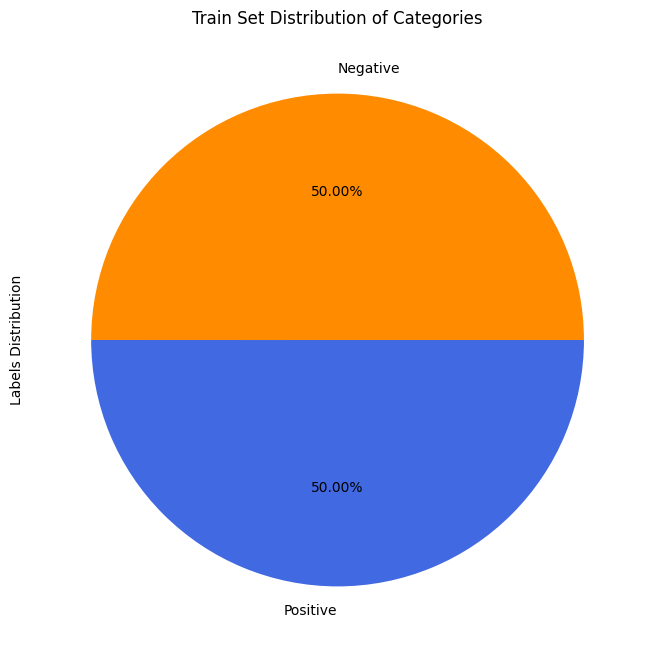

In [21]:
labels_count = df_train['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Train Set Distribution of Categories')

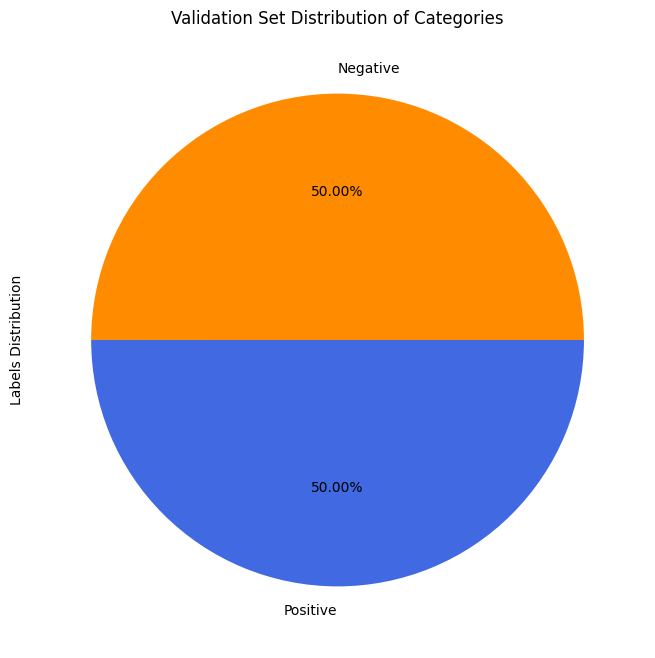

In [22]:
labels_count = df_val['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Validation Set Distribution of Categories')

### Creating a wordcloud using the tweet texts on train set before preprocessing

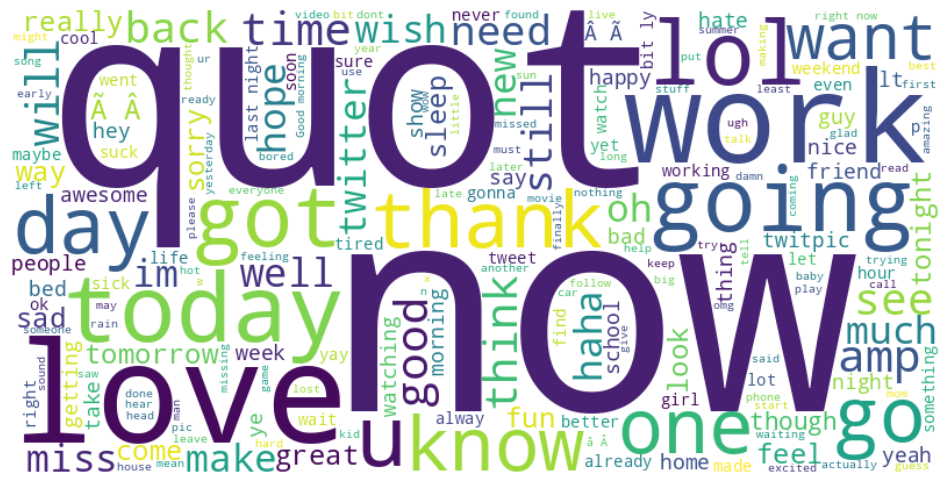

In [23]:
create_wordcloud(df_train['Text'])

### Creating a wordcloud by using only the positive tweets before preprocessing

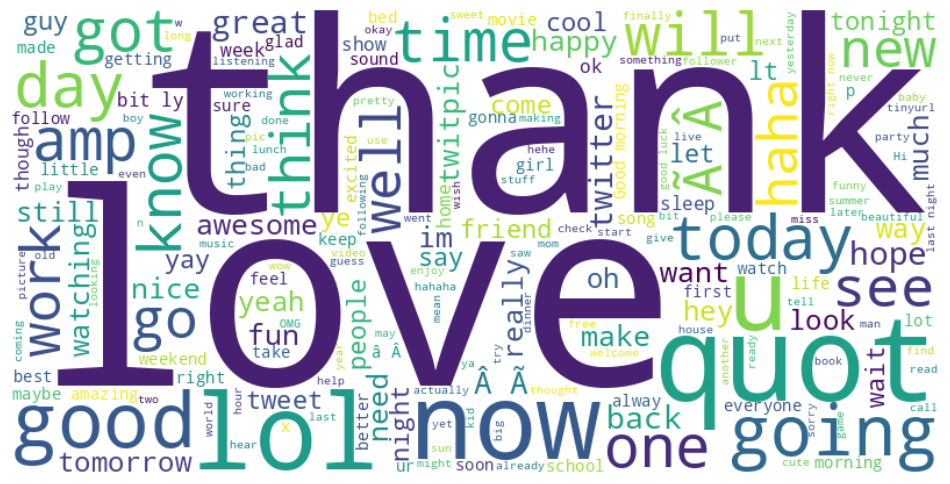

In [24]:
create_wordcloud(df_train[df_train['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets before preprocessing

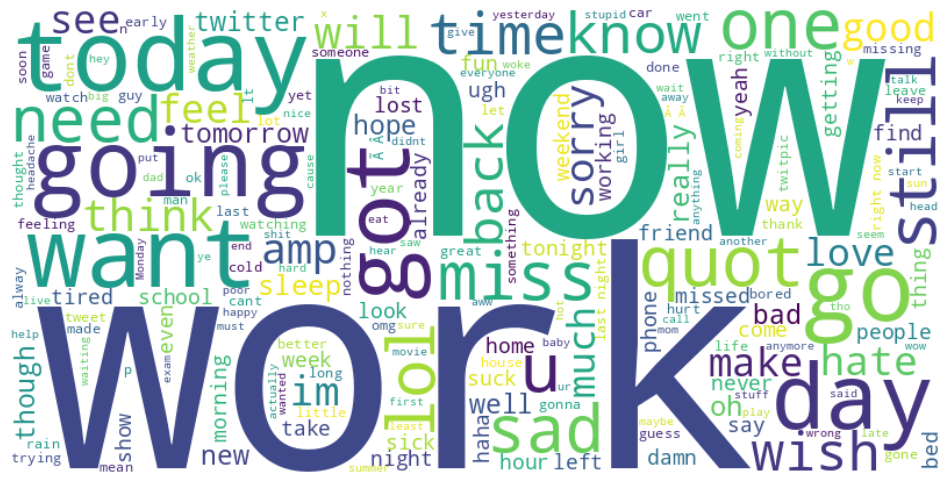

In [25]:
create_wordcloud(df_train[df_train['Label'] == 0]['Text'])

### Plotting a histogram with tweets length across the dataset

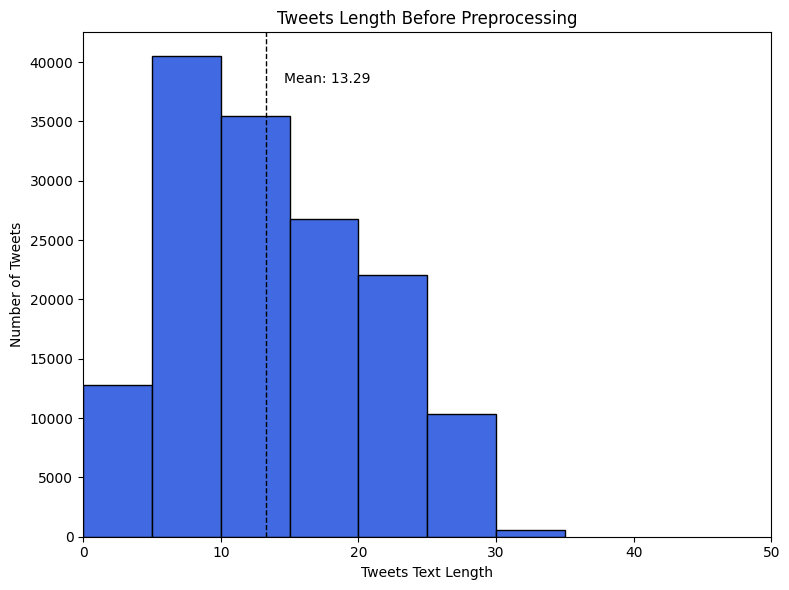

In [26]:
tweets_length = get_tweets_length(df_train)
plot_histogram(tweets_length, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length Before Preprocessing')

### Plotting minimum and maximum length of tweets on train set

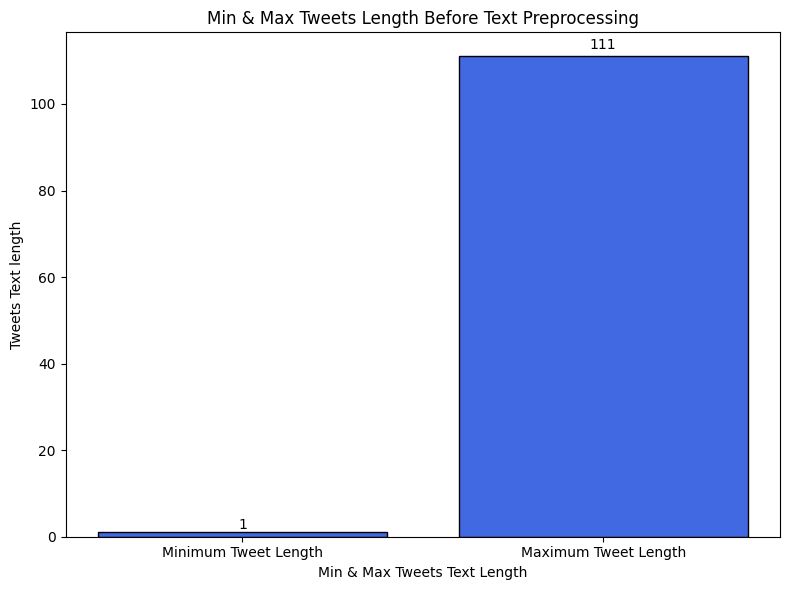

In [27]:
df_min_max = get_min_max_tweets(tweets_length)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Text Length', 'Tweets Text length', 'Min & Max Tweets Length Before Text Preprocessing', False, False, True)

### Plotting the most common words (unigrams) of train dataset

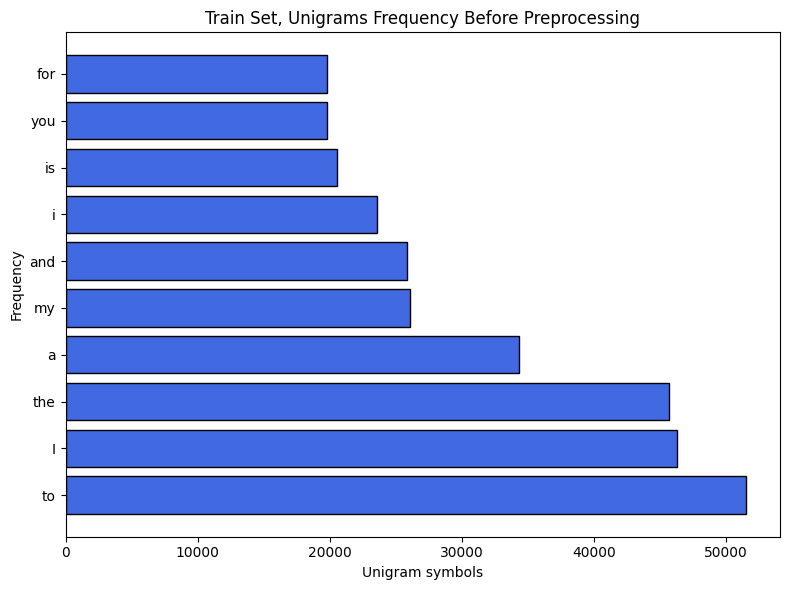

In [28]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train, top=10, n=1)] + ['Unigram symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency Before Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset

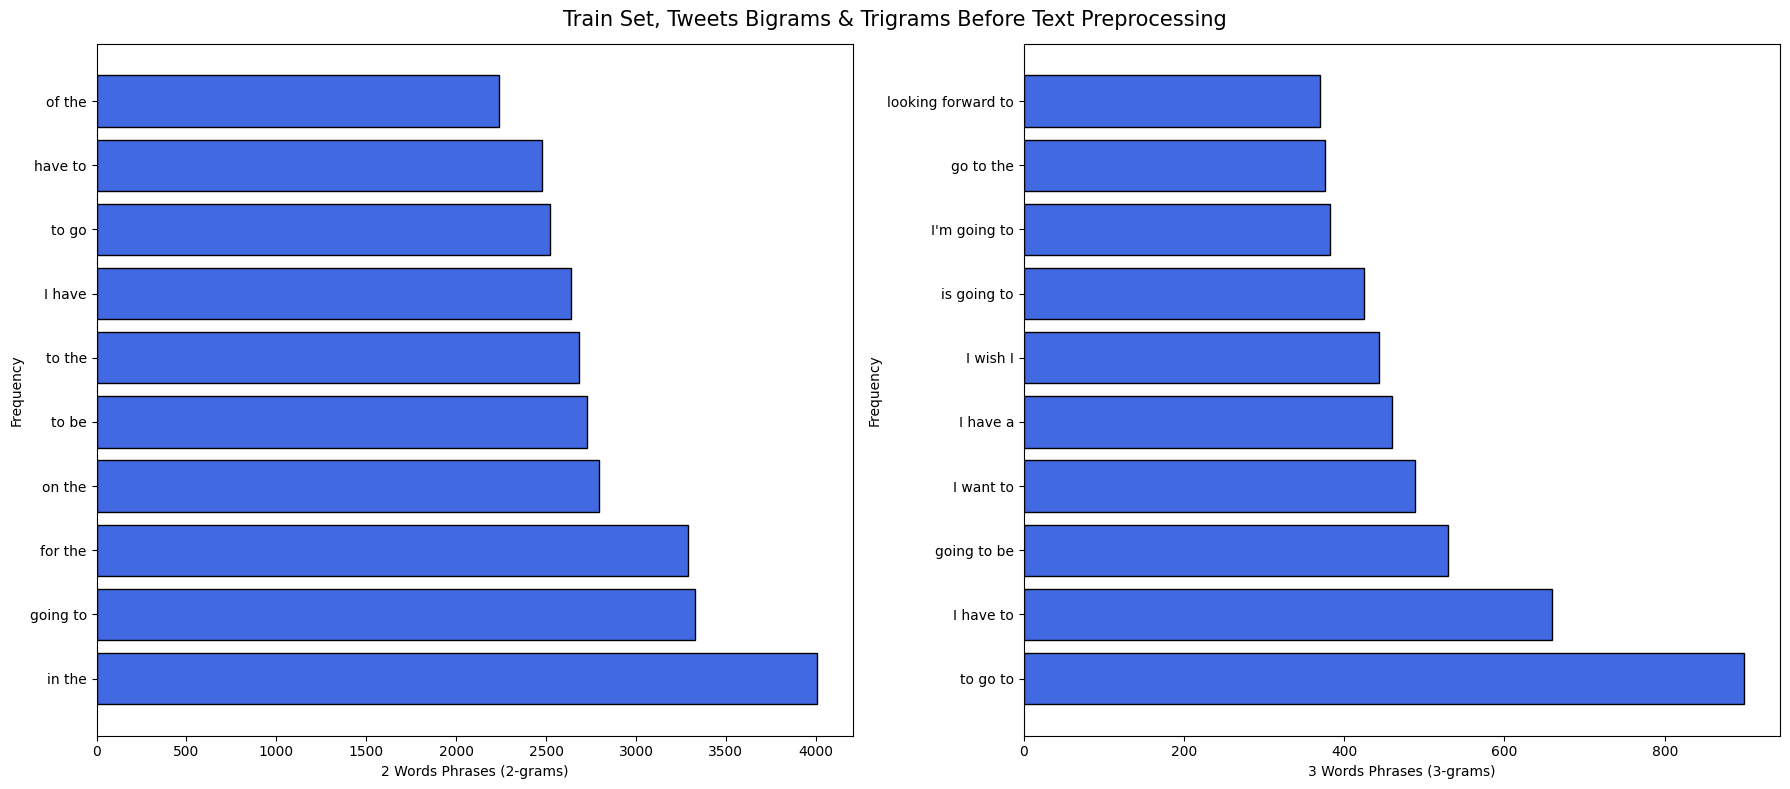

In [29]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams Before Text Preprocessing', bary=True)

### Plotting the number of emails and user mentions found in train dataset (Log Scale)

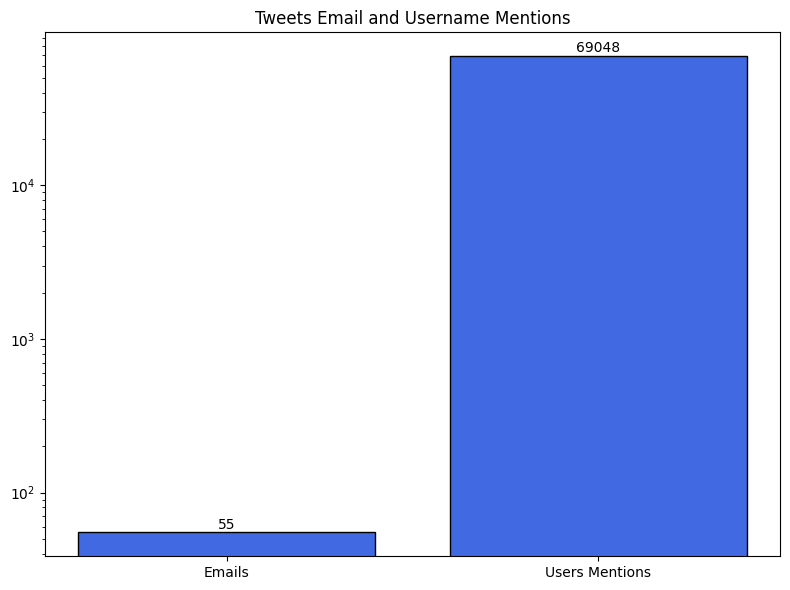

In [30]:
emails_count = df_train.loc[df_train['Text'].str.contains(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{1,}\b'), :].shape[0]

user_mentions_count = df_train.loc[df_train['Text'].str.contains(r'(?<![\w.])@\w+'), :].shape[0]

plot_bar(['Emails', 'Users Mentions'], [emails_count, user_mentions_count], '', '', 'Tweets Email and Username Mentions', False, True, True)

## NLP Text Preprocessing on Tweets

In [31]:
nltk.download('punkt', quiet=True);
nltk.download('stopwords', quiet=True);
nltk.download('wordnet', quiet=True);

# !unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

In [32]:
abbreviations = {
    "$" : " dollar ",
    "€" : " euro ",
    "4ao" : "for adults only",
    "a.m" : "before midday",
    "a3" : "anytime anywhere anyplace",
    "aamof" : "as a matter of fact",
    "acct" : "account",
    "adih" : "another day in hell",
    "afaic" : "as far as i am concerned",
    "afaict" : "as far as i can tell",
    "afaik" : "as far as i know",
    "afair" : "as far as i remember",
    "afk" : "away from keyboard",
    "app" : "application",
    "approx" : "approximately",
    "apps" : "applications",
    "asap" : "as soon as possible",
    "asl" : "age, sex, location",
    "atk" : "at the keyboard",
    "ave." : "avenue",
    "aymm" : "are you my mother",
    "ayor" : "at your own risk", 
    "b&b" : "bed and breakfast",
    "b+b" : "bed and breakfast",
    "b.c" : "before christ",
    "b2b" : "business to business",
    "b2c" : "business to customer",
    "b4" : "before",
    "b4n" : "bye for now",
    "b@u" : "back at you",
    "bae" : "before anyone else",
    "bak" : "back at keyboard",
    "bbbg" : "bye bye be good",
    "bbc" : "british broadcasting corporation",
    "bbias" : "be back in a second",
    "bbl" : "be back later",
    "bbs" : "be back soon",
    "be4" : "before",
    "bfn" : "bye for now",
    "blvd" : "boulevard",
    "bout" : "about",
    "brb" : "be right back",
    "bros" : "brothers",
    "brt" : "be right there",
    "bsaaw" : "big smile and a wink",
    "btw" : "by the way",
    "bwl" : "bursting with laughter",
    "c/o" : "care of",
    "cet" : "central european time",
    "cf" : "compare",
    "cia" : "central intelligence agency",
    "csl" : "can not stop laughing",
    "cu" : "see you",
    "cul8r" : "see you later",
    "cv" : "curriculum vitae",
    "cwot" : "complete waste of time",
    "cya" : "see you",
    "cyt" : "see you tomorrow",
    "dae" : "does anyone else",
    "dbmib" : "do not bother me i am busy",
    "diy" : "do it yourself",
    "dm" : "direct message",
    "dwh" : "during work hours",
    "e123" : "easy as one two three",
    "eet" : "eastern european time",
    "eg" : "example",
    "embm" : "early morning business meeting",
    "encl" : "enclosed",
    "encl." : "enclosed",
    "etc" : "and so on",
    "faq" : "frequently asked questions",
    "fawc" : "for anyone who cares",
    "fb" : "facebook",
    "fc" : "fingers crossed",
    "fig" : "figure",
    "fimh" : "forever in my heart", 
    "ft." : "feet",
    "ft" : "featuring",
    "ftl" : "for the loss",
    "ftw" : "for the win",
    "fwiw" : "for what it is worth",
    "fyi" : "for your information",
    "g9" : "genius",
    "gahoy" : "get a hold of yourself",
    "gal" : "get a life",
    "gcse" : "general certificate of secondary education",
    "gfn" : "gone for now",
    "gg" : "good game",
    "gl" : "good luck",
    "glhf" : "good luck have fun",
    "gmt" : "greenwich mean time",
    "gmta" : "great minds think alike",
    "gn" : "good night",
    "g.o.a.t" : "greatest of all time",
    "goat" : "greatest of all time",
    "goi" : "get over it",
    "gps" : "global positioning system",
    "gr8" : "great",
    "gratz" : "congratulations",
    "gyal" : "girl",
    "h&c" : "hot and cold",
    "hp" : "horsepower",
    "hr" : "hour",
    "hrh" : "his royal highness",
    "ht" : "height",
    "ibrb" : "i will be right back",
    "ic" : "i see",
    "icq" : "i seek you",
    "icymi" : "in case you missed it",
    "idc" : "i do not care",
    "idgadf" : "i do not give a damn fuck",
    "idgaf" : "i do not give a fuck",
    "idk" : "i do not know",
    "ie" : "that is",
    "i.e" : "that is",
    "ifyp" : "i feel your pain",
    "IG" : "instagram",
    "iirc" : "if i remember correctly",
    "ilu" : "i love you",
    "ily" : "i love you",
    "imho" : "in my humble opinion",
    "imo" : "in my opinion",
    "imu" : "i miss you",
    "iow" : "in other words",
    "irl" : "in real life",
    "j4f" : "just for fun",
    "jic" : "just in case",
    "jk" : "just kidding",
    "jsyk" : "just so you know",
    "l8r" : "later",
    "lb" : "pound",
    "lbs" : "pounds",
    "ldr" : "long distance relationship",
    "lmao" : "laugh my ass off",
    "lmfao" : "laugh my fucking ass off",
    "lol" : "laughing out loud",
    "ltd" : "limited",
    "ltns" : "long time no see",
    "m8" : "mate",
    "mf" : "motherfucker",
    "mfs" : "motherfuckers",
    "mfw" : "my face when",
    "mofo" : "motherfucker",
    "mph" : "miles per hour",
    "mr" : "mister",
    "mrw" : "my reaction when",
    "ms" : "miss",
    "mte" : "my thoughts exactly",
    "nagi" : "not a good idea",
    "nbc" : "national broadcasting company",
    "nbd" : "not big deal",
    "nfs" : "not for sale",
    "ngl" : "not going to lie",
    "nhs" : "national health service",
    "nrn" : "no reply necessary",
    "nsfl" : "not safe for life",
    "nsfw" : "not safe for work",
    "nth" : "nice to have",
    "nvr" : "never",
    "nyc" : "new york city",
    "oc" : "original content",
    "og" : "original",
    "ohp" : "overhead projector",
    "oic" : "oh i see",
    "omdb" : "over my dead body",
    "omg" : "oh my god",
    "omw" : "on my way",
    "p.a" : "per annum",
    "p.m" : "after midday",
    "pm" : "prime minister",
    "poc" : "people of color",
    "pov" : "point of view",
    "pp" : "pages",
    "ppl" : "people",
    "prw" : "parents are watching",
    "ps" : "postscript",
    "pt" : "point",
    "ptb" : "please text back",
    "pto" : "please turn over",
    "qpsa" : "what happens", #"que pasa",
    "ratchet" : "rude",
    "rbtl" : "read between the lines",
    "rlrt" : "real life retweet", 
    "rofl" : "rolling on the floor laughing",
    "roflol" : "rolling on the floor laughing out loud",
    "rotflmao" : "rolling on the floor laughing my ass off",
    "rt" : "retweet",
    "ruok" : "are you ok",
    "sfw" : "safe for work",
    "sk8" : "skate",
    "smh" : "shake my head",
    "sq" : "square",
    "srsly" : "seriously", 
    "ssdd" : "same stuff different day",
    "tbh" : "to be honest",
    "tbs" : "tablespooful",
    "tbsp" : "tablespooful",
    "tfw" : "that feeling when",
    "thks" : "thank you",
    "tho" : "though",
    "thx" : "thank you",
    "tia" : "thanks in advance",
    "til" : "today i learned",
    "tl;dr" : "too long i did not read",
    "tldr" : "too long i did not read",
    "tmb" : "tweet me back",
    "tntl" : "trying not to laugh",
    "ttyl" : "talk to you later",
    "u" : "you",
    "u2" : "you too",
    "u4e" : "yours for ever",
    "utc" : "coordinated universal time",
    "w/" : "with",
    "w/o" : "without",
    "w8" : "wait",
    "wassup" : "what is up",
    "wb" : "welcome back",
    "wtf" : "what the fuck",
    "wtg" : "way to go",
    "wtpa" : "where the party at",
    "wuf" : "where are you from",
    "wuzup" : "what is up",
    "wywh" : "wish you were here",
    "yd" : "yard",
    "ygtr" : "you got that right",
    "ynk" : "you never know",
    "zzz" : "sleeping bored and tired"
}


In [33]:
def convert_abbrev(word):
    return abbreviations[word] if word in abbreviations.keys() else word

### Text Preprocessing is done on two phases to determine which is the best configuration for out dataset
- Preprocessing with stop words filtering
- Preprocessing with stop words preservation

### The `preprocess_text` function applies the following preprocessing steps:
- **Lowercasing**: Converts all characters to lowercase.
- **Expanding Contractions**: Expanding combinations of words that are shortened.
- **Removing Punctuation Except '@' for Emails and User Mentions**: Eliminating the punctuation of tweets.
- **Anonymizing Mentions**: Username mentions in tweets are converted to '@user'.
- **Anonymizing Email Addresses**: Email addresses are converted to 'XXX@email.com'.
- **Removing URLs**: Removing URLs from text.
- **Removing Digits**: Removing all numeric characters within tweets.
- **Filtering Stop Words**: If 'filter_stopwords' is true then stop words are removed from tweets.
- **Covert Slang Words**: If 'convert_slang' is true then filter slang abbreviations.
- **Lemmatization**: Coverts the words to their base form.

In [34]:
punctuation = string.punctuation.replace('@', '')
lemmatizer = WordNetLemmatizer()
tokenizer = TweetTokenizer()

def preprocess_text(text, filter_stopwords=False, convert_slang=False):
    text = text.lower()
    text = contractions.fix(text)
    
    text = text.translate(str.maketrans('', '', punctuation))
    
    text = re.sub(r'(?<![\w.])@\w+', '', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\b', '', text)
    
    text = re.sub(r"http\S+", "", text)
    
    tokens = tokenizer.tokenize(text)
    
    if filter_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]
    
    if convert_slang:
        tokens = [convert_abbrev(word) for word in tokens]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    text = re.sub(r'\d+', '', ' '.join(tokens))

    return text


### Removing rows with zero text length (after doing preprocessing) only on train and validation datasets

In [35]:
def filter_non_empty(df):
    return df[df['Text'].str.split().str.len() != 0]

### Function `clean_dataset` does the following steps:
- Creates a copy of the dataframe.
- Removes non-ascii characters from tweets.
- Runs the `preprocess_text` function to further preprocess the tweets (explained above).
- Removes any row with zero text length (on train and validation set only).

In [36]:
def clean_dataset(df, filter_stopwords=False, filter_rows=True, convert_slang=False):
    df_clean = df.copy()
    df_clean['Text'] = df_clean['Text'].str.encode('ascii', 'ignore').str.decode('ascii')
    df_clean['Text'] = df_clean['Text'].apply(preprocess_text, filter_stopwords=filter_stopwords, convert_slang=convert_slang)
    return filter_non_empty(df_clean) if filter_rows else df_clean

### Running tweets preprocessing on train, validation and test set with filtering stop words activated

In [37]:
df_train_cln = clean_dataset(df_train, filter_stopwords=True, convert_slang=True)
df_val_cln = clean_dataset(df_val, filter_stopwords=True, convert_slang=True)
df_test_cln = clean_dataset(df_test, filter_stopwords=True, filter_rows=False, convert_slang=True)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep   = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

### Displaying the dimenstions of train, validation and test dataset matrices

In [38]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X validation Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y validation Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (147596,)
y train Preprocessed Dimensions: (147596,)
X validation Preprocessed Dimensions: (42188,)
y validation Preprocessed Dimensions: (42188,)
X test Preprocessed Dimensions: (21199,)


### Checking the tweets after running preprocessing

In [39]:
df_train_cln.head()

,ID,Text,Label
0,189385,dude bummed leaving,0
1,58036,oh god severed foot foun wheely bin cobham fou...,0
2,190139,end quotdog dialingquot sumtimes dog dialing a...,1
3,99313,meeeee toooooo,0
4,157825,hoping could stay home work today look like ma...,0


In [40]:
df_val_cln.head()

,ID,Text,Label
0,187062,heyheyhey maybe get could find would cannot fi...,0
1,168997,work work crap missed condescending overbearin...,0
2,194461,want trip boston next month need additl motiva...,1
3,165442,first day start tomorrow,1
4,34853,course fish little saigon dessert place cocon...,1


## Exploratory Data Analysis After Running Text Preprocessing (With Stop Words Filtering)

### Plotting a histogram with tweets length across the training dataset after preprocessing

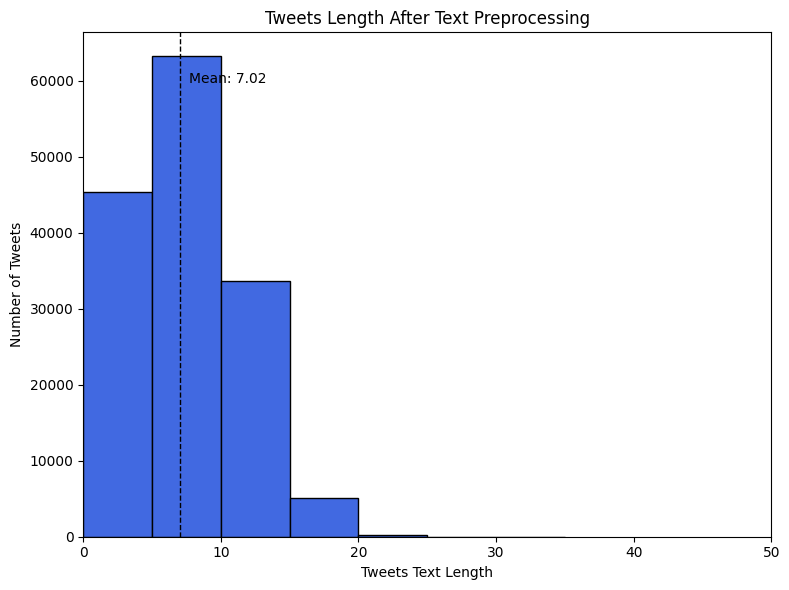

In [41]:
tweets_length_clean = get_tweets_length(df_train_cln)
plot_histogram(tweets_length_clean, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length After Text Preprocessing')

### Plotting minimum and maximum length of tweets after running preprocessing

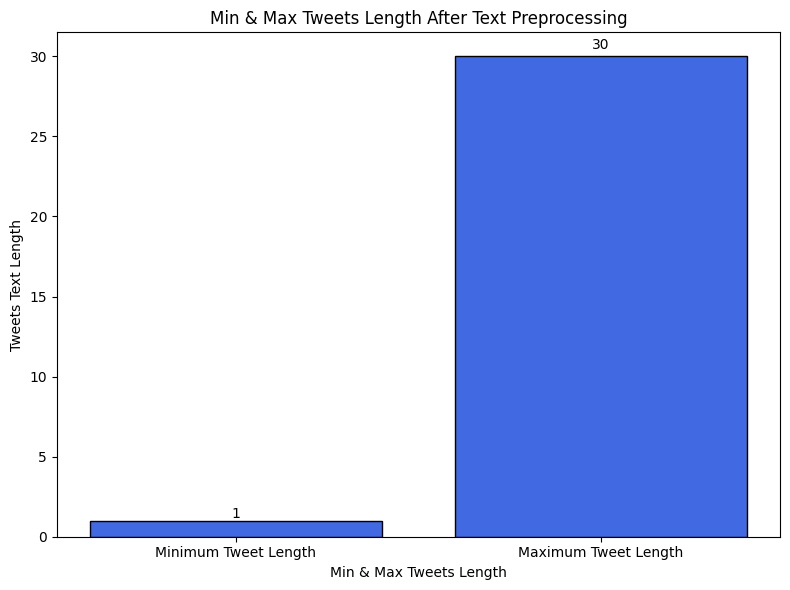

In [42]:
df_min_max = get_min_max_tweets(tweets_length_clean)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Length', 'Tweets Text Length', 'Min & Max Tweets Length After Text Preprocessing', False, False, True)

### Creating a wordcloud using the tweet texts on train set after running preprocessing

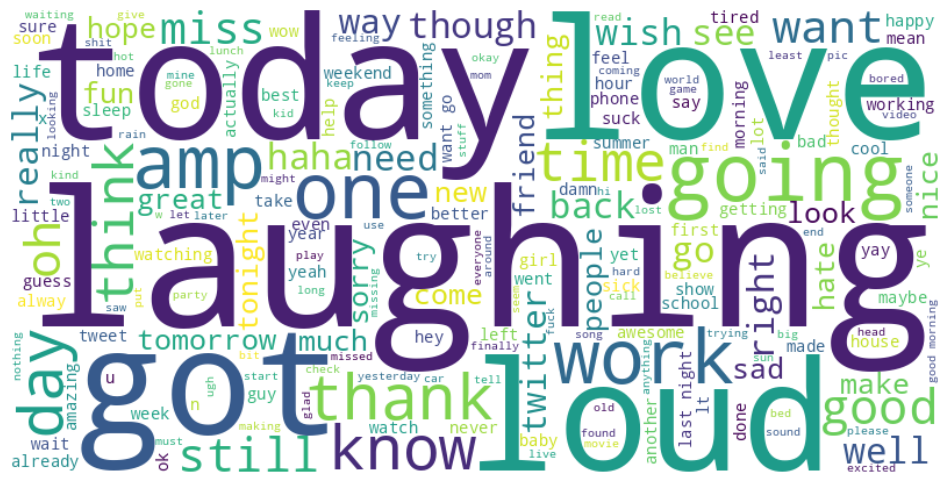

In [43]:
create_wordcloud(df_train_cln['Text'])

### Creating a wordcloud by using only the positive tweets after running preprocessing

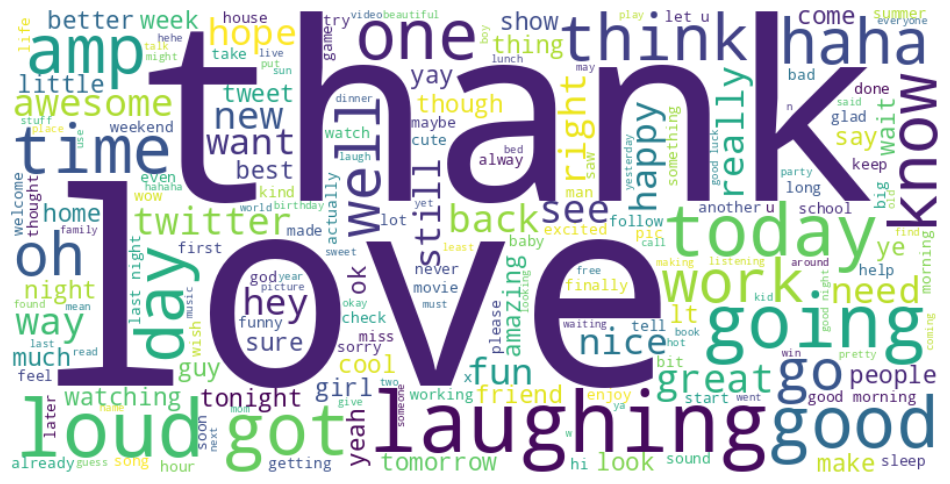

In [44]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets after running preprocessing

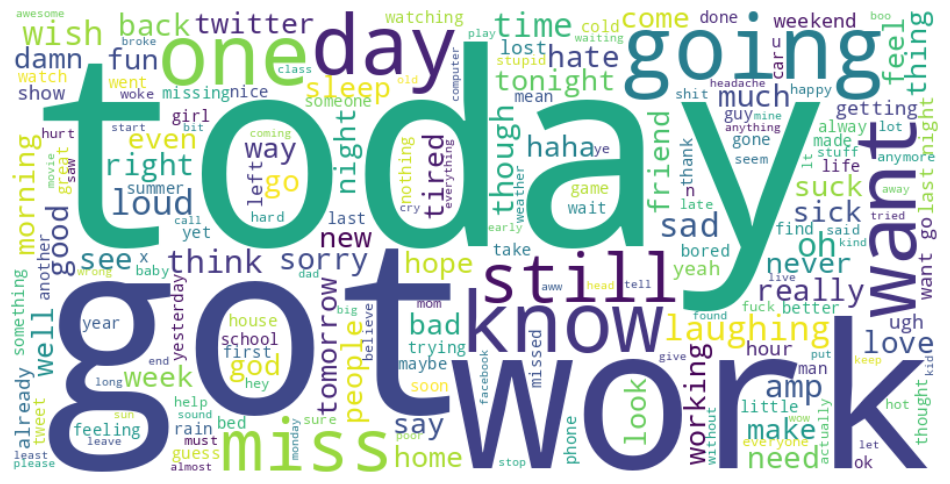

In [45]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 0]['Text'])

### Plotting the most common words (unigrams) of train dataset after running preprocessing

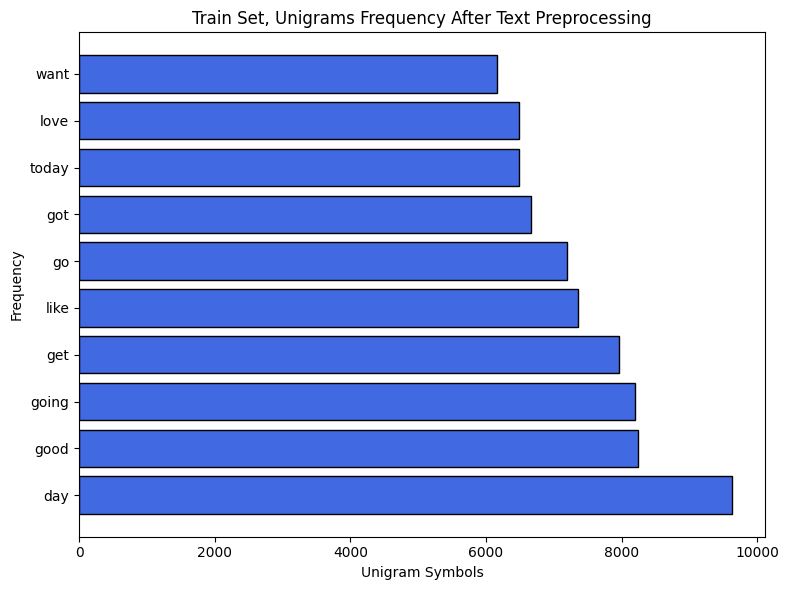

In [46]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency After Text Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset after running preprocessing

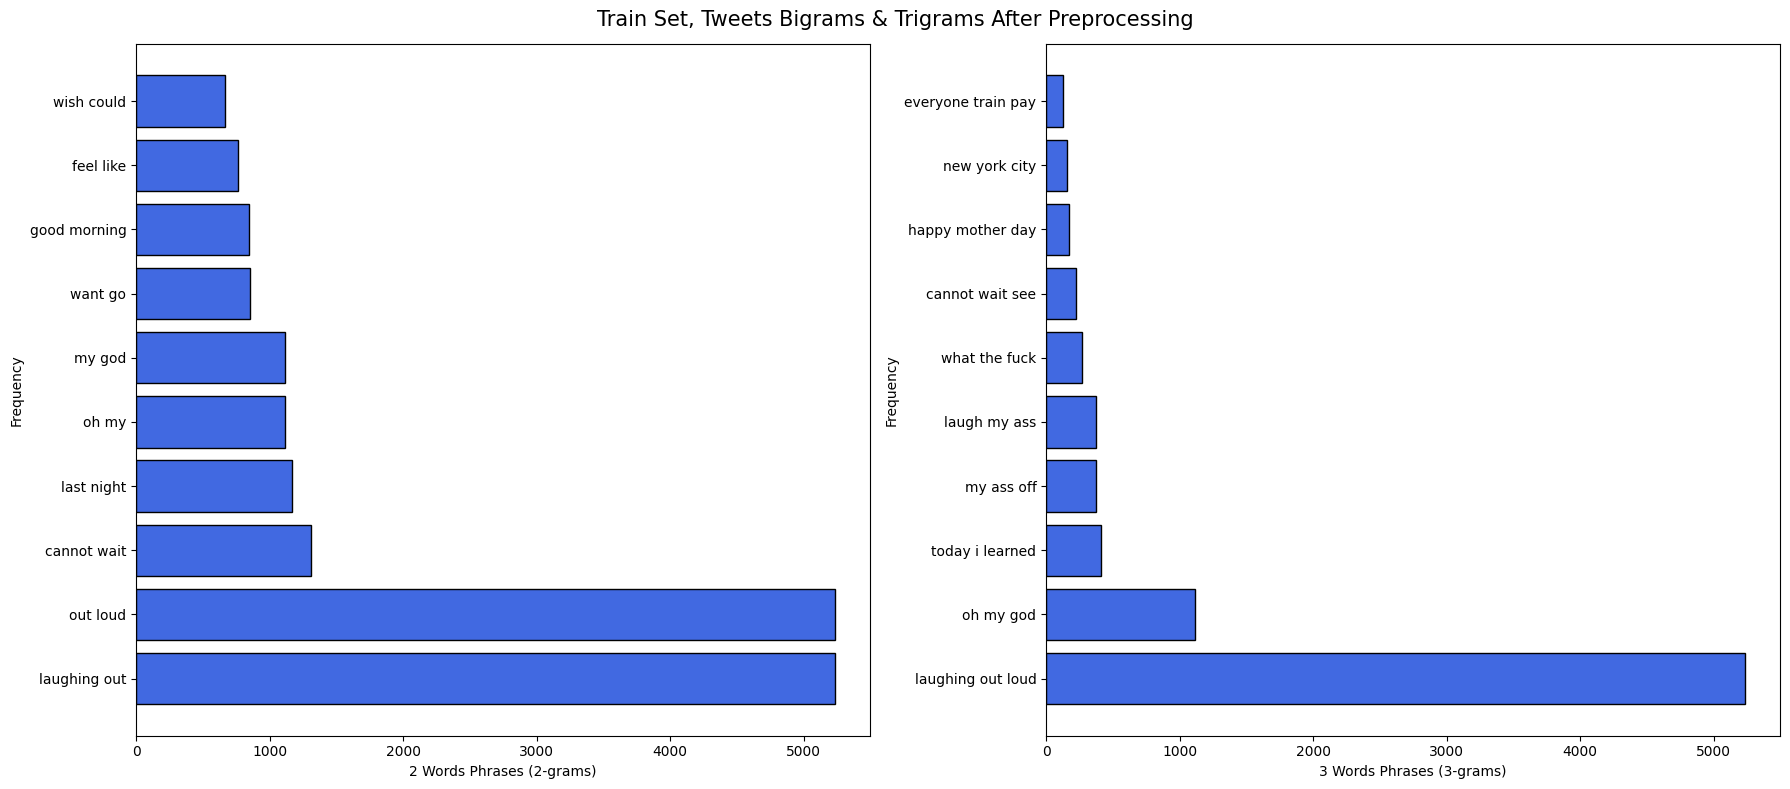

In [47]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

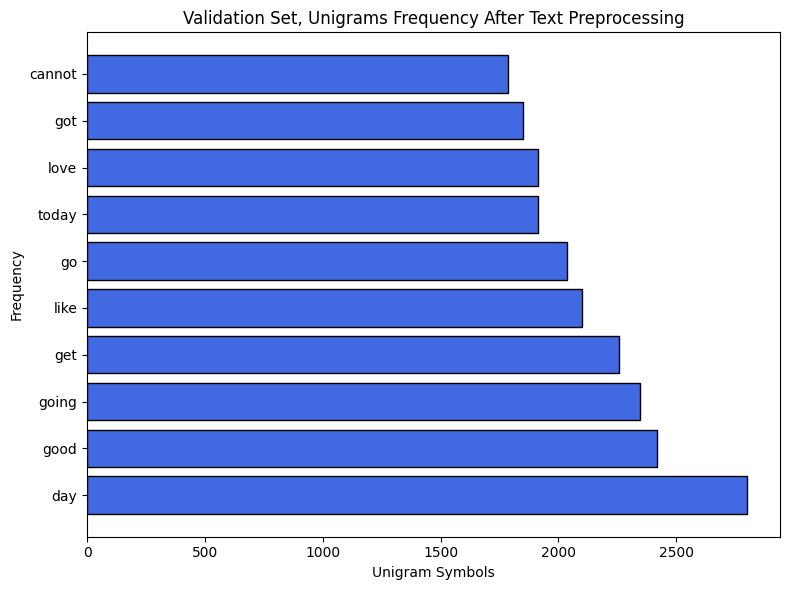

In [48]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Validation Set, Unigrams Frequency After Text Preprocessing', bary=True)

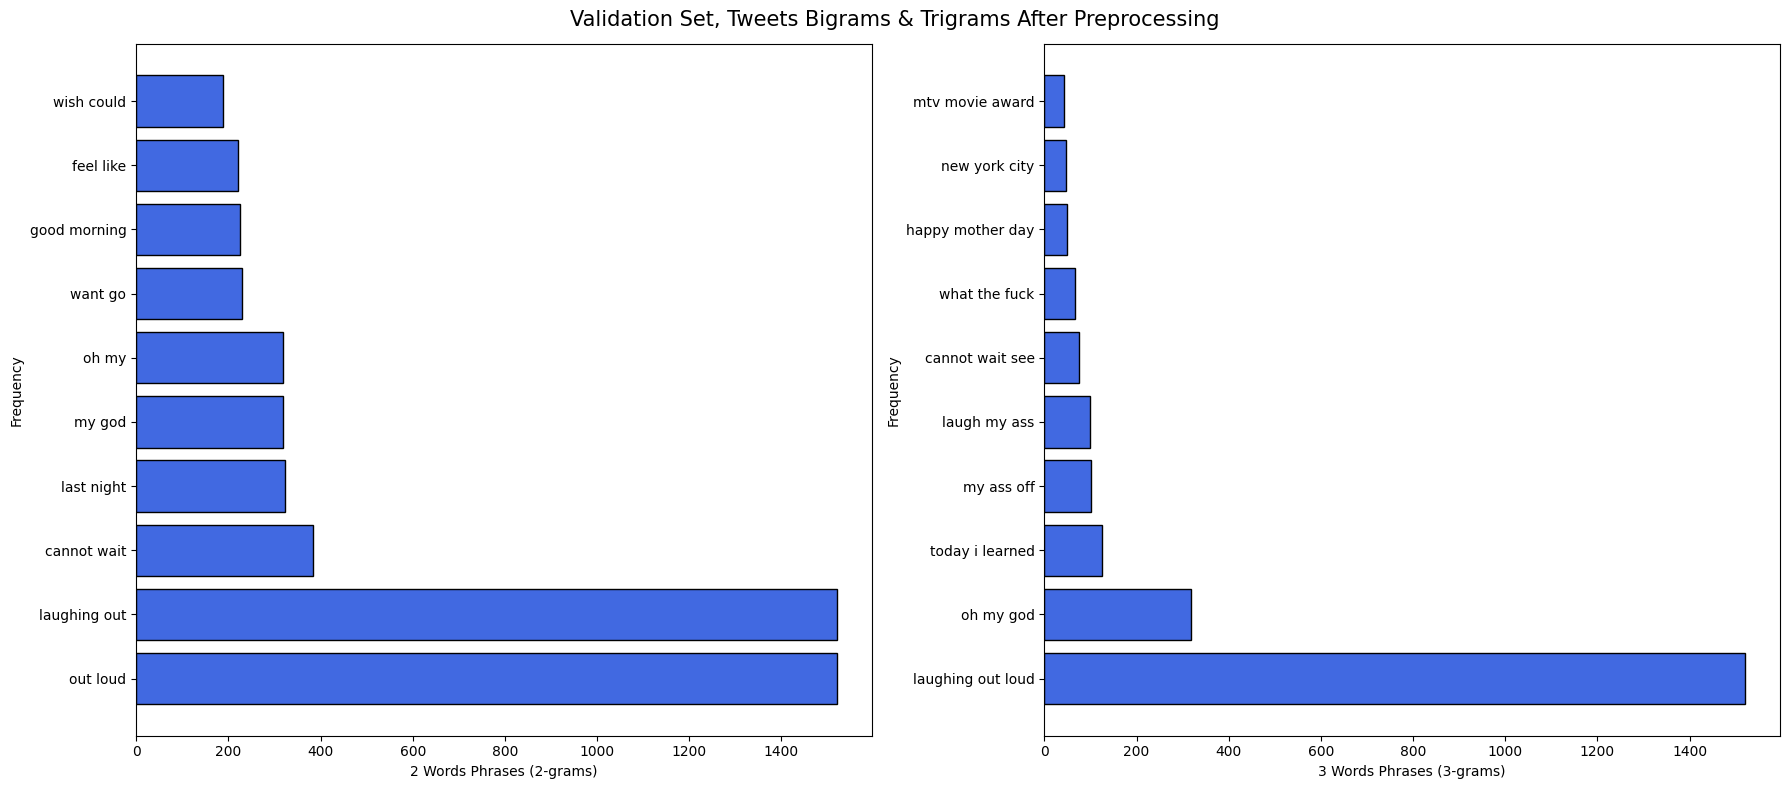

In [49]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Validation Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

## Feature Extraction: Word2Vec using GoogleNews pretrained vectors

#### The acronyms used on preprocessing experimentations are the following: 

#### - **PRFS**: Preprocessing & Filtering Stopwords
#### - **PRPS**: Preprocessing & Preserving Stopwords

### Function that calculates **Accuracy**, **Precission**, **Recall** and **F1 scores** and returns a dictionary object

In [50]:
def calc_model_score(y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

### Function that plots the final scores (accuracy, precision, recall, F1) of a Neural Network model on the best epoch

In [51]:
def plot_best_scores(results, title):
    keys = ['best_epoch_accuracy', 'best_epoch_precision', 'best_epoch_recall', 'best_epoch_f1']
    label_mapping = {
        'best_epoch_accuracy': 'Accuracy',
        'best_epoch_precision': 'Precision',
        'best_epoch_recall': 'Recall',
        'best_epoch_f1': 'F1'
    }
    colors_list = ['#1C77C3', '#F34213', '#E0CA3C', '#3E2F5B']
    
    scores = [results[key] * 100 for key in keys]
    labels = [label_mapping[key] for key in keys]

    _, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, scores, color=colors_list, edgecolor="black")

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}%", ha='center', va='bottom')
    
    ax.set_ylabel("Score (%)")
    ax.set_title(title)
    ax.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.show()

### Function that plots model scores & training, validation losses for each epoch

In [52]:
def plot_epochs_scores(results, title):
    grouped = {
        'Loss': ['Train Loss', 'Validation Loss'],
        'Accuracy': ['Train Accuracy', 'Validation Accuracy']
    }

    single = [key for key in results if key not in grouped['Loss'] and key not in grouped['Accuracy']]
    fig = plt.figure(figsize=(15, 8))
    fig.suptitle(title, fontsize=16)

    outer = gridspec.GridSpec(2, 1)

    gs_1 = gridspec.GridSpecFromSubplotSpec(1, 2, outer[0], wspace=0.3)
    ax1 = fig.add_subplot(gs_1[0, 0])
    ax2 = fig.add_subplot(gs_1[0, 1])
    for ax, (group_name, keys) in zip([ax1, ax2], grouped.items()):
        for key in keys:
            ax.plot(results[key], marker='o', label=key)
        ax.set_title(group_name, fontsize=12)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(group_name, fontsize=10)
        ax.grid(True)
        ax.legend(fontsize=8)

    gs_2 = gridspec.GridSpecFromSubplotSpec(1, 3, outer[1], wspace=0.3)
    ax_bot1 = fig.add_subplot(gs_2[0, 0])
    ax_bot2 = fig.add_subplot(gs_2[0, 1])
    ax_bot3 = fig.add_subplot(gs_2[0, 2])
    for ax, key in zip([ax_bot1, ax_bot2, ax_bot3], single):
        ax.plot(results[key], marker='o')
        ax.set_title(key, fontsize=12)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(key, fontsize=10)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

### Function that calculates the ROC curve

In [53]:
def calc_roc_curve(y, y_pred):
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

### Function that plots the ROC curve

In [54]:
def plot_roc_curve(fpr, tpr, roc_auc, estimator_name):
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=estimator_name)
    display.plot()
    plt.show()

### Function that calculates the confusion matrix, given the classification labels

In [55]:
def calc_confusion_matrix(y, y_pred):
    return confusion_matrix(y, y_pred)

### Function that plots the confusion matrix

In [56]:
def plot_confusion_matrix(cm):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

### Loading GoogleNews pretrained vectos in a Word2Vec format. The dimensions of the embeddings are 300

In [57]:
embeddings_dim = 300
word2vec_google = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

### Function that converts each token of every tweet into an embedding using the GoogleNews Word2Vec vectors. If a token is not found on Word2Vec we skip it so it does not get included when we calculare the average values vector of each tweet

In [58]:
def tokens_to_embeddings(df_tokens, word2vec_google, embeddings_dim):
    embeddings = []
    for tokens in df_tokens:
        vecs = []
        for token in tokens:
            if token in word2vec_google:
                vecs.append(word2vec_google[token])

        if len(vecs) == 0:  # for empty test set data just put zeros as an embedding vector
            embeddings.append(torch.zeros(1, embeddings_dim))
        else:
            embeddings.append(torch.tensor(np.array(vecs), dtype=torch.float32))
            
    return embeddings

### Function that calculates the mean embedding of each tweet (each entry in our dataset)

In [59]:
def get_mean_embeddings(X, word2vec_google, embeddings_dim):
    tknzr = TweetTokenizer()
    toks = X.apply(lambda x: tknzr.tokenize(x))
    X = tokens_to_embeddings(toks, word2vec_google, embeddings_dim)
    X = torch.stack([torch.mean(sentence, dim=0) for sentence in X])
    X_tensor = X.view(X.size(0), -1)
    return X_tensor

### Function that returns the best results based on the maximum accuracy

In [60]:
def get_best_results(results):
    return max(results, key=lambda c: c[1]['best_epoch_accuracy'])

### A generic neural network class, which is used to configure our model however we want during the evaluation

In [61]:
class NeuralNet(nn.Module):
    def __init__(self, D_in, hidden_sizes, D_out=1, activations=None, dropout=0, enable_batch_norm=False):
        super(NeuralNet, self).__init__()

        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        self.activations = activations
        self.D_in = D_in
        self.D_out = D_out
        self.enable_batch_norm = enable_batch_norm

        if activations is None:
            activations = [nn.ReLU] * len(hidden_sizes)

        layers = []
        in_dim = D_in

        for activation_func, hidden_layer in zip(activations, hidden_sizes):
            layers.append(nn.Linear(in_dim, hidden_layer))
            
            if enable_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_layer))
            
            layers.append(activation_func())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
                
            in_dim = hidden_layer

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(in_dim, D_out)
        
    def forward(self, x):
        x = self.hidden_layers(x)
        return self.output_layer(x)

### Function that trains a neural network model. It is used to train our model for epochs and calculated the train set loss

In [62]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    return epoch_loss

### Function that evaluates the model, calculates the validation set loss and all the remaining model scores

In [63]:
def evaluate_model(model, dataloader, loss_fn, device):
    model.eval()
    y_pred_list = []
    y_true_list = []
    total_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            
            total_loss += loss_fn(y_pred, y_batch).item()
            
            y_pred = torch.sigmoid(y_pred)
            y_pred = (y_pred > 0.5).float()
            
            y_pred_list.append(y_pred.cpu().numpy())
            y_true_list.append(y_batch.cpu().numpy())
    
    y_pred_list = np.concatenate(y_pred_list)
    y_true_list = np.concatenate(y_true_list)
    
    avg_loss = total_loss / len(dataloader)
    
    return {**calc_model_score(y_true_list, y_pred_list), 'loss': avg_loss}


### Function that prints model's performance evaluation score including train and validation losses

In [64]:
def print_epoch_scores(print_res, epoch, n_epochs, train_loss, train_metrics , val_metrics):
    if epoch % print_res == 0:
        print(f"Epoch {epoch}/{n_epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Acc: {train_metrics['Accuracy']:.4f} | "
            f"Val Acc: {val_metrics['Accuracy']:.4f} | "
            f"Val Precision: {val_metrics['Precision']:.4f} | "
            f"Val Recall: {val_metrics['Recall']:.4f} | "
            f"Val F1: {val_metrics['F1 Score']:.4f}"
        )

### Function that trains a neural network model over multiple epochs, evaluates performance on training and validation sets and supports early stopping. Stores model scores such as loss, accuracy, precision, recall, and F1 score for each epoch

In [65]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, n_epochs, device, early=False, print_res=1):

    results = {
        'Train Loss': [], 
        'Validation Loss': [],
        'Train Accuracy': [], 
        'Validation Accuracy': [],
        'Validation Precision': [],
        'Validation Recall': [],
        'Validation F1 Score': []
    }
    
    no_loss_improve = 0
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 1

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device=device)
        
        train_metrics = evaluate_model(model, train_loader, loss_fn=loss_fn, device=device)
        val_metrics = evaluate_model(model, val_loader, loss_fn=loss_fn, device=device) 

        results['Train Loss'].append(train_loss)
        results['Validation Loss'].append(val_metrics['loss'])
        
        results['Train Accuracy'].append(train_metrics['Accuracy'])
        results['Validation Accuracy'].append(val_metrics['Accuracy'])
        results['Validation Precision'].append(val_metrics['Precision'])
        results['Validation Recall'].append(val_metrics['Recall'])
        results['Validation F1 Score'].append(val_metrics['F1 Score'])

        print_epoch_scores(print_res, epoch, n_epochs, train_loss, train_metrics , val_metrics)
        
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            no_loss_improve = 0
            best_epoch = epoch
            results['best_epoch_val_loss'] = best_val_loss
            results['best_epoch_accuracy'] = val_metrics['Accuracy']
            results['best_epoch_precision'] = val_metrics['Precision']
            results['best_epoch_recall'] = val_metrics['Recall']
            results['best_epoch_f1'] = val_metrics['F1 Score']

            best_state = model.state_dict()
        else:
            no_loss_improve += 1

        if early and no_loss_improve >= 3:
            print(f"Early stopping triggered after {epoch} epochs.")
            print(f"Best model found at epoch {best_epoch} with validation loss {best_val_loss:.4f}")
            model.load_state_dict(best_state)
            break
    
    return results

### Transforming preprocessed text tweets embedding tokens and then into mean embeddings using the Google Word2Vec model for train, validation, and test sets

In [66]:
X_train_tensor = get_mean_embeddings(X_train_prep, word2vec_google, embeddings_dim)
X_val_tensor = get_mean_embeddings(X_val_prep, word2vec_google, embeddings_dim)
X_test_tensor = get_mean_embeddings(X_test_prep, word2vec_google, embeddings_dim)

X_train_tensor

tensor([[ 0.2386,  0.0474,  0.0171,  ..., -0.1367,  0.0045, -0.0616],
        [ 0.0428,  0.0567, -0.0160,  ..., -0.0109, -0.0832,  0.0077],
        [ 0.0108, -0.0014, -0.0331,  ...,  0.0101, -0.0620,  0.0194],
        ...,
        [ 0.0760, -0.0213, -0.0212,  ..., -0.0421,  0.0513,  0.0312],
        [ 0.0975,  0.0192,  0.0548,  ..., -0.0897,  0.0093, -0.0805],
        [ 0.0604,  0.0756, -0.0974,  ..., -0.1177, -0.0937,  0.0775]])

### Converting classification labels to Tensors

In [67]:
y_train_tensor = torch.tensor(y_train_prep.values).float().unsqueeze(1)
y_val_tensor = torch.tensor(y_val_prep.values).float().unsqueeze(1)

### Creating dataloaders for the train and validation datasets

In [68]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

### Selecting GPU for pytorch else CPU

In [69]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Training a neural network with hidden layers [128, 64], ReLU activations, Adam optimizer, and BCEWithLogitsLoss for 50 epochs

### This model runs using the preprocessed tweets with filtered stopswords enabled (PRFS)

Epoch 5/50 | Train Loss: 0.4871 | Val Loss: 0.5064 | Train Acc: 0.7705 | Val Acc: 0.7508 | Val Precision: 0.7331 | Val Recall: 0.7885 | Val F1: 0.7598
Epoch 10/50 | Train Loss: 0.4504 | Val Loss: 0.5146 | Train Acc: 0.7961 | Val Acc: 0.7444 | Val Precision: 0.7656 | Val Recall: 0.7044 | Val F1: 0.7338
Epoch 15/50 | Train Loss: 0.4157 | Val Loss: 0.5461 | Train Acc: 0.8114 | Val Acc: 0.7364 | Val Precision: 0.7114 | Val Recall: 0.7955 | Val F1: 0.7511
Epoch 20/50 | Train Loss: 0.3875 | Val Loss: 0.5736 | Train Acc: 0.8359 | Val Acc: 0.7340 | Val Precision: 0.7302 | Val Recall: 0.7422 | Val F1: 0.7361
Epoch 25/50 | Train Loss: 0.3636 | Val Loss: 0.6153 | Train Acc: 0.8493 | Val Acc: 0.7306 | Val Precision: 0.7282 | Val Recall: 0.7358 | Val F1: 0.7320
Epoch 30/50 | Train Loss: 0.3437 | Val Loss: 0.6598 | Train Acc: 0.8611 | Val Acc: 0.7239 | Val Precision: 0.7169 | Val Recall: 0.7399 | Val F1: 0.7282
Epoch 35/50 | Train Loss: 0.3255 | Val Loss: 0.7083 | Train Acc: 0.8619 | Val Acc: 0.7199

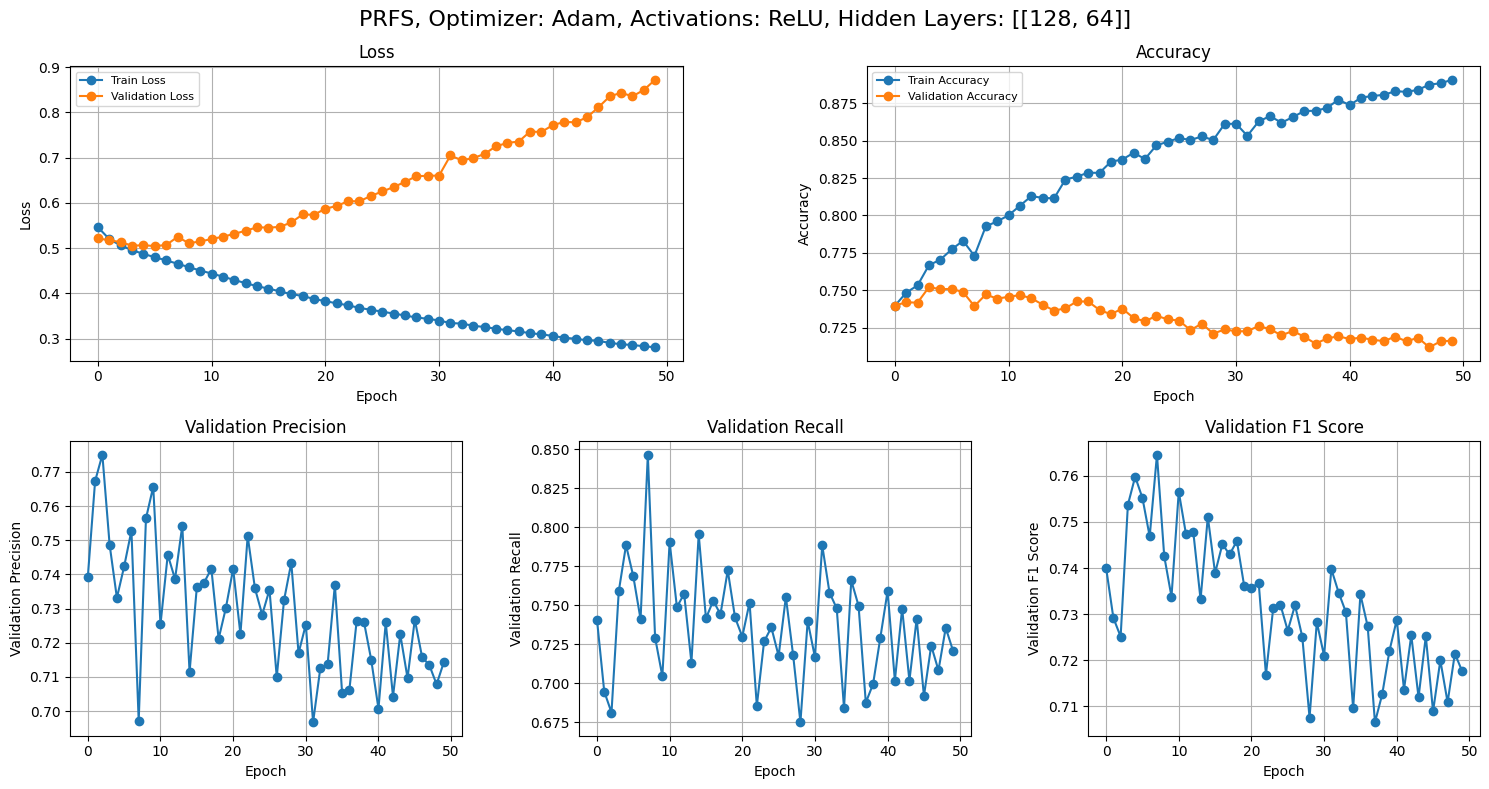

In [ ]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader, 
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=5
)

plot_epochs_scores(results, f'PRFS, Optimizer: Adam, Activations: ReLU, Hidden Layers: {[128, 64]}')

### Preprocessing tweets text without filtering stop words (PRPS) to compare it with the previous evaluation (PRFS)

In [71]:
df_train_cln = clean_dataset(df_train, filter_stopwords=False, convert_slang=True)
df_val_cln = clean_dataset(df_val, filter_stopwords=False, convert_slang=True)
df_test_cln = clean_dataset(df_test, filter_stopwords=False, filter_rows=False, convert_slang=True)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

In [72]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X_val Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y val Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148048,)
y train Preprocessed Dimensions: (148048,)
X_val Preprocessed Dimensions: (42316,)
y val Preprocessed Dimensions: (42316,)
X test Preprocessed Dimensions: (21199,)


### Transforming preprocessed text tweets embedding tokens and then into mean embeddings using the Google Word2Vec model for train, validation, and test sets

In [73]:
X_train_tensor = get_mean_embeddings(X_train_prep, word2vec_google, embeddings_dim)
X_val_tensor = get_mean_embeddings(X_val_prep, word2vec_google, embeddings_dim)
X_test_tensor = get_mean_embeddings(X_test_prep, word2vec_google, embeddings_dim)

X_train_tensor

tensor([[ 0.0467,  0.0016,  0.0450,  ..., -0.0860,  0.0221,  0.0172],
        [ 0.0496,  0.0504,  0.0271,  ..., -0.0240, -0.0179, -0.0055],
        [ 0.0344,  0.0036,  0.0420,  ...,  0.0119, -0.0646,  0.0034],
        ...,
        [ 0.0111, -0.0245,  0.0076,  ..., -0.0351,  0.0211,  0.0161],
        [ 0.0849,  0.0140,  0.0580,  ..., -0.0790,  0.0151, -0.0880],
        [ 0.0371,  0.0651,  0.0040,  ..., -0.0538, -0.0440,  0.0299]])

### Converting classification labels to Tensors

In [74]:
y_train_tensor = torch.tensor(y_train_prep.values).float().unsqueeze(1)
y_val_tensor = torch.tensor(y_val_prep.values).float().unsqueeze(1)

### Creating dataloaders for the train and validation datasets

In [75]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

### Training a neural network with hidden layers [128, 64], ReLU activations, Adam optimizer, and BCEWithLogitsLoss for 50 epochs

### This model runs using the preprocessed tweets with preserved stopswords enabled (PRPS)

Epoch 5/50 | Train Loss: 0.4682 | Val Loss: 0.4783 | Train Acc: 0.7821 | Val Acc: 0.7702 | Val Precision: 0.7918 | Val Recall: 0.7329 | Val F1: 0.7612
Epoch 10/50 | Train Loss: 0.4377 | Val Loss: 0.4766 | Train Acc: 0.8030 | Val Acc: 0.7705 | Val Precision: 0.7607 | Val Recall: 0.7891 | Val F1: 0.7747
Epoch 15/50 | Train Loss: 0.4126 | Val Loss: 0.4920 | Train Acc: 0.8179 | Val Acc: 0.7679 | Val Precision: 0.7849 | Val Recall: 0.7379 | Val F1: 0.7606
Epoch 20/50 | Train Loss: 0.3881 | Val Loss: 0.5090 | Train Acc: 0.8318 | Val Acc: 0.7639 | Val Precision: 0.7618 | Val Recall: 0.7678 | Val F1: 0.7648
Epoch 25/50 | Train Loss: 0.3671 | Val Loss: 0.5367 | Train Acc: 0.8414 | Val Acc: 0.7592 | Val Precision: 0.7698 | Val Recall: 0.7392 | Val F1: 0.7542
Epoch 30/50 | Train Loss: 0.3504 | Val Loss: 0.5740 | Train Acc: 0.8500 | Val Acc: 0.7619 | Val Precision: 0.7775 | Val Recall: 0.7334 | Val F1: 0.7548
Epoch 35/50 | Train Loss: 0.3339 | Val Loss: 0.6005 | Train Acc: 0.8570 | Val Acc: 0.7532

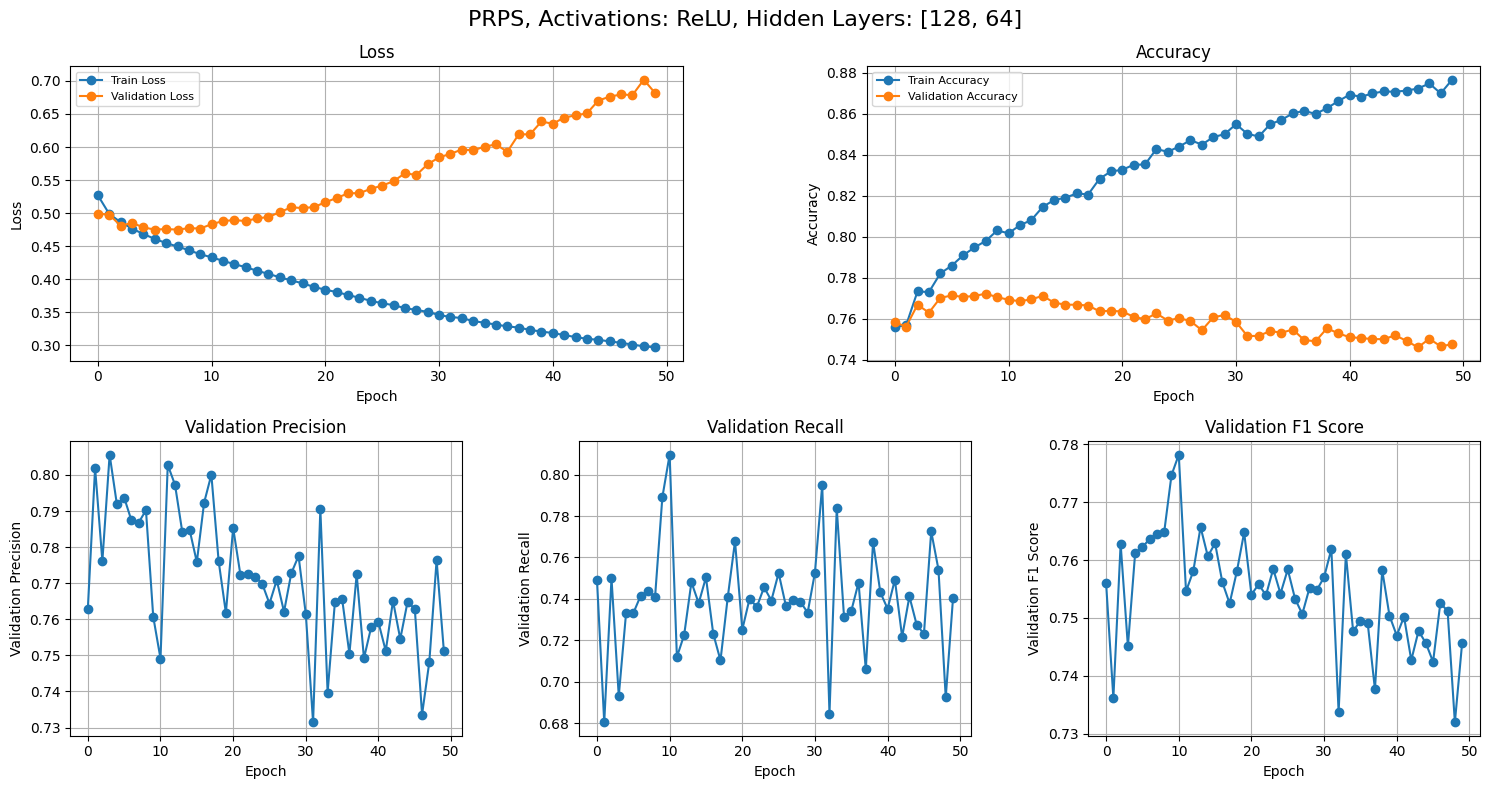

In [76]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader,
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=5
)

plot_epochs_scores(results, f'PRPS, Activations: ReLU, Hidden Layers: {[128, 64]}')

#### We observe that keeping stopwords in the tweet text leads to better validation accuracy. Therefore, in the following experiments, we retain stopwords during preprocessing. However, both previous models show signs of overfitting, with increasing validation loss across epochs. We address this issue in the next experiments

### Addressing the overfitting issue by introducing dropout on each layer to improve generalization on the validation set

Epoch 10/50 | Train Loss: 0.4851 | Val Loss: 0.4793 | Train Acc: 0.7794 | Val Acc: 0.7692 | Val Precision: 0.7527 | Val Recall: 0.8016 | Val F1: 0.7764
Epoch 20/50 | Train Loss: 0.4688 | Val Loss: 0.4720 | Train Acc: 0.7936 | Val Acc: 0.7757 | Val Precision: 0.7804 | Val Recall: 0.7672 | Val F1: 0.7737
Epoch 30/50 | Train Loss: 0.4596 | Val Loss: 0.4708 | Train Acc: 0.8025 | Val Acc: 0.7758 | Val Precision: 0.7751 | Val Recall: 0.7767 | Val F1: 0.7759
Epoch 40/50 | Train Loss: 0.4514 | Val Loss: 0.4733 | Train Acc: 0.8063 | Val Acc: 0.7745 | Val Precision: 0.7900 | Val Recall: 0.7476 | Val F1: 0.7682
Epoch 50/50 | Train Loss: 0.4461 | Val Loss: 0.4718 | Train Acc: 0.8117 | Val Acc: 0.7750 | Val Precision: 0.7676 | Val Recall: 0.7886 | Val F1: 0.7779


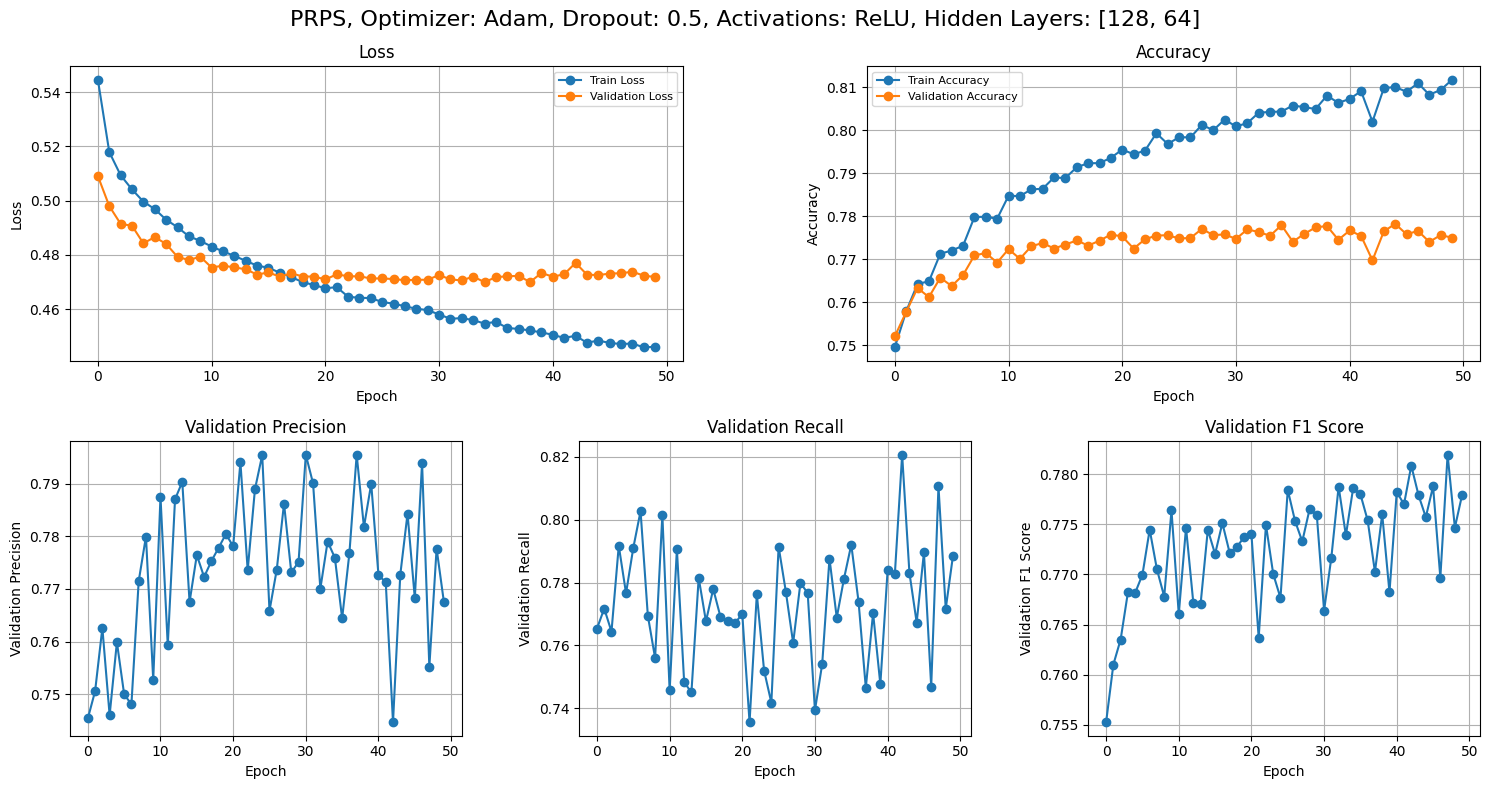

In [77]:
model = NeuralNet(D_in=X_train_tensor.shape[1], hidden_sizes=[128, 64], dropout=0.5, D_out=1, activations=[nn.ReLU, nn.ReLU]).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model, 
    train_loader, 
    val_loader, 
    loss_fn, 
    optimizer, 
    n_epochs=50,
    device=device,
    print_res=5
)

plot_epochs_scores(results, f'PRPS, Optimizer: Adam, Dropout: 0.5, Activations: ReLU, Hidden Layers: {[128, 64]}')

### We experiment with different neural network architectures, testing hidden layer sizes of 2, 3, and 4. The network uses ReLU activations on each layer, the Adam optimizer with a learning rate of 1e-3, and dropout (0.5) to address overfitting

In [78]:
hidden_sizes_list = [
    [128, 64],
    [256, 128],
    [256, 128, 64],
    [256, 256, 128],
    [512, 256, 128],
    [128, 128, 64, 32],
    [256, 128, 64, 32],
    [256, 256, 128, 64],
    [512, 256, 128, 64]
]

nn_configs_list = []

for hidden_sizes in hidden_sizes_list:
    nn_configs_list.append({
        'D_in': X_train_tensor.shape[1],
        'hidden_sizes': hidden_sizes,
        'D_out': 1,
        'activations': [nn.ReLU] * len(hidden_sizes),
        'dropout': 0.5
    })

### We train the model for a maximum of 50 epochs and introduce **early stopping** if the validation loss does not decrease for 3 epoch steps to address overfitting issues. Final model scores are evaluated using the best epoch step (lowest validation loss of the model)

Epoch 1/50 | Train Loss: 0.5431 | Val Loss: 0.5092 | Train Acc: 0.7495 | Val Acc: 0.7511 | Val Precision: 0.7955 | Val Recall: 0.6759 | Val F1: 0.7308
Epoch 2/50 | Train Loss: 0.5176 | Val Loss: 0.4982 | Train Acc: 0.7606 | Val Acc: 0.7603 | Val Precision: 0.7614 | Val Recall: 0.7581 | Val F1: 0.7597
Epoch 3/50 | Train Loss: 0.5089 | Val Loss: 0.4909 | Train Acc: 0.7663 | Val Acc: 0.7649 | Val Precision: 0.7785 | Val Recall: 0.7402 | Val F1: 0.7589
Epoch 4/50 | Train Loss: 0.5037 | Val Loss: 0.4872 | Train Acc: 0.7675 | Val Acc: 0.7644 | Val Precision: 0.7557 | Val Recall: 0.7813 | Val F1: 0.7683
Epoch 5/50 | Train Loss: 0.4998 | Val Loss: 0.4852 | Train Acc: 0.7706 | Val Acc: 0.7677 | Val Precision: 0.7861 | Val Recall: 0.7352 | Val F1: 0.7598
Epoch 6/50 | Train Loss: 0.4951 | Val Loss: 0.4821 | Train Acc: 0.7741 | Val Acc: 0.7691 | Val Precision: 0.7877 | Val Recall: 0.7367 | Val F1: 0.7613
Epoch 7/50 | Train Loss: 0.4919 | Val Loss: 0.4804 | Train Acc: 0.7766 | Val Acc: 0.7678 | Val

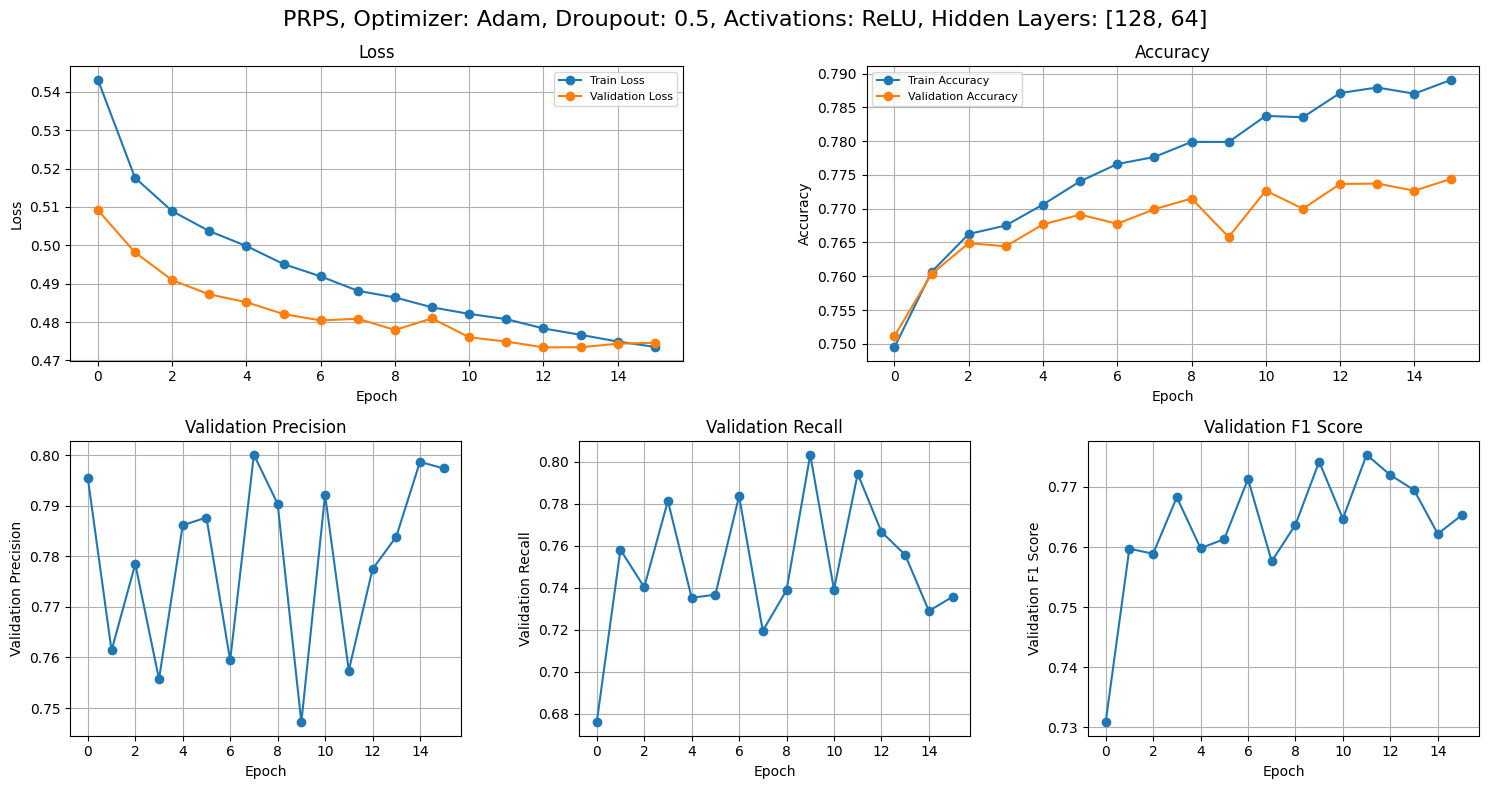

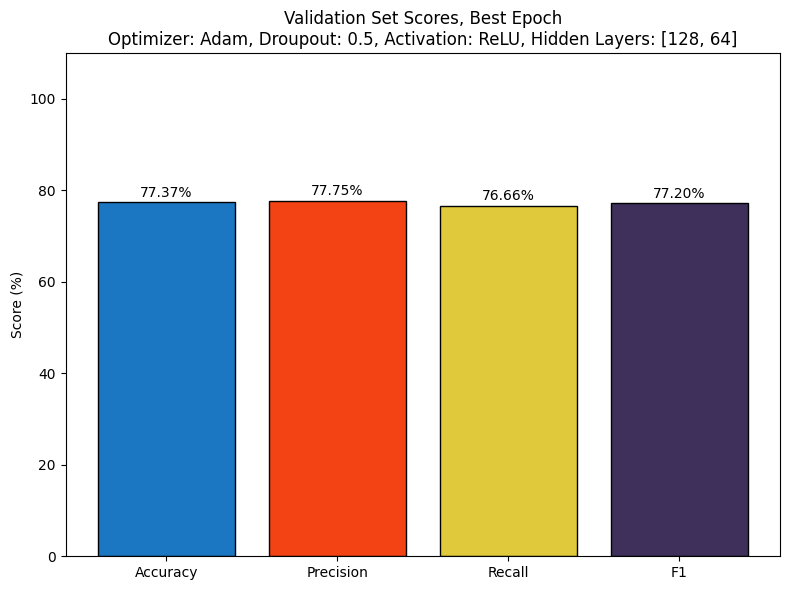

Epoch 1/50 | Train Loss: 0.5366 | Val Loss: 0.5020 | Train Acc: 0.7528 | Val Acc: 0.7552 | Val Precision: 0.7590 | Val Recall: 0.7475 | Val F1: 0.7532
Epoch 2/50 | Train Loss: 0.5115 | Val Loss: 0.4933 | Train Acc: 0.7616 | Val Acc: 0.7622 | Val Precision: 0.7743 | Val Recall: 0.7399 | Val F1: 0.7567
Epoch 3/50 | Train Loss: 0.5025 | Val Loss: 0.4910 | Train Acc: 0.7629 | Val Acc: 0.7609 | Val Precision: 0.7366 | Val Recall: 0.8119 | Val F1: 0.7724
Epoch 4/50 | Train Loss: 0.4963 | Val Loss: 0.4833 | Train Acc: 0.7710 | Val Acc: 0.7677 | Val Precision: 0.7699 | Val Recall: 0.7635 | Val F1: 0.7667
Epoch 5/50 | Train Loss: 0.4908 | Val Loss: 0.4797 | Train Acc: 0.7736 | Val Acc: 0.7680 | Val Precision: 0.7675 | Val Recall: 0.7688 | Val F1: 0.7681
Epoch 6/50 | Train Loss: 0.4858 | Val Loss: 0.4789 | Train Acc: 0.7778 | Val Acc: 0.7695 | Val Precision: 0.7852 | Val Recall: 0.7418 | Val F1: 0.7629
Epoch 7/50 | Train Loss: 0.4819 | Val Loss: 0.4803 | Train Acc: 0.7776 | Val Acc: 0.7691 | Val

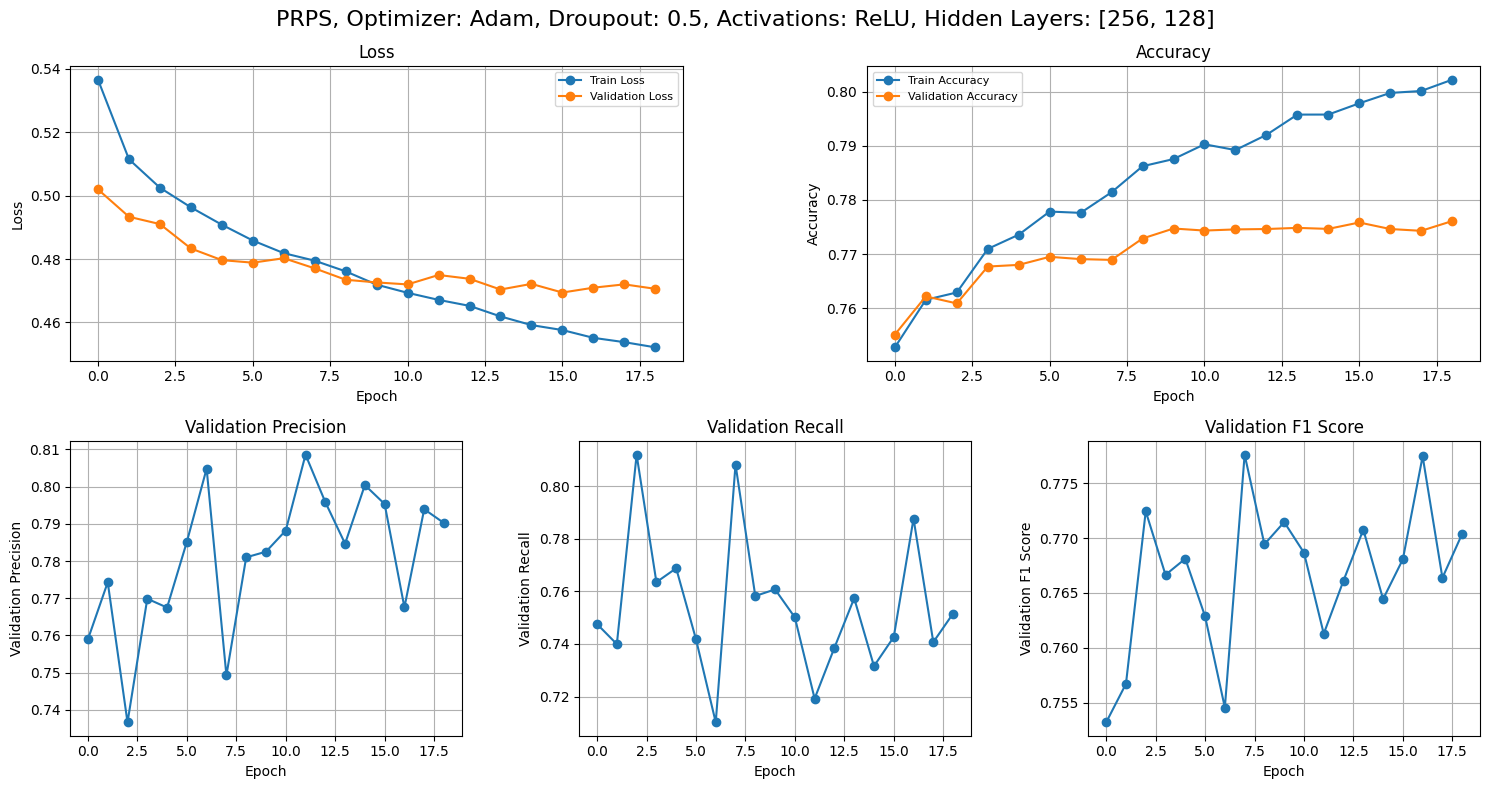

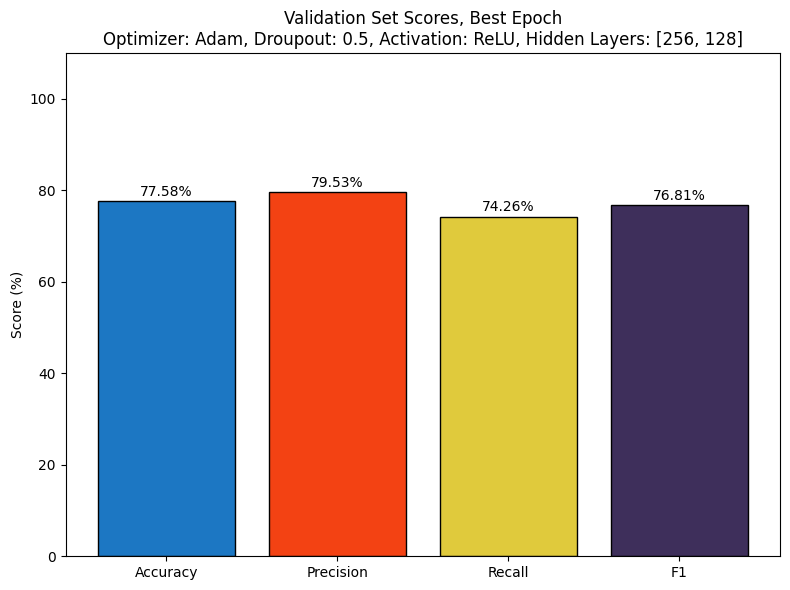

Epoch 1/50 | Train Loss: 0.5441 | Val Loss: 0.5036 | Train Acc: 0.7525 | Val Acc: 0.7539 | Val Precision: 0.7841 | Val Recall: 0.7006 | Val F1: 0.7400
Epoch 2/50 | Train Loss: 0.5157 | Val Loss: 0.4972 | Train Acc: 0.7591 | Val Acc: 0.7576 | Val Precision: 0.7406 | Val Recall: 0.7927 | Val F1: 0.7658
Epoch 3/50 | Train Loss: 0.5070 | Val Loss: 0.4902 | Train Acc: 0.7643 | Val Acc: 0.7618 | Val Precision: 0.7723 | Val Recall: 0.7422 | Val F1: 0.7570
Epoch 4/50 | Train Loss: 0.5004 | Val Loss: 0.4851 | Train Acc: 0.7711 | Val Acc: 0.7643 | Val Precision: 0.7690 | Val Recall: 0.7554 | Val F1: 0.7621
Epoch 5/50 | Train Loss: 0.4955 | Val Loss: 0.4796 | Train Acc: 0.7753 | Val Acc: 0.7662 | Val Precision: 0.7621 | Val Recall: 0.7738 | Val F1: 0.7679
Epoch 6/50 | Train Loss: 0.4911 | Val Loss: 0.4771 | Train Acc: 0.7785 | Val Acc: 0.7705 | Val Precision: 0.7850 | Val Recall: 0.7447 | Val F1: 0.7644
Epoch 7/50 | Train Loss: 0.4872 | Val Loss: 0.4798 | Train Acc: 0.7778 | Val Acc: 0.7689 | Val

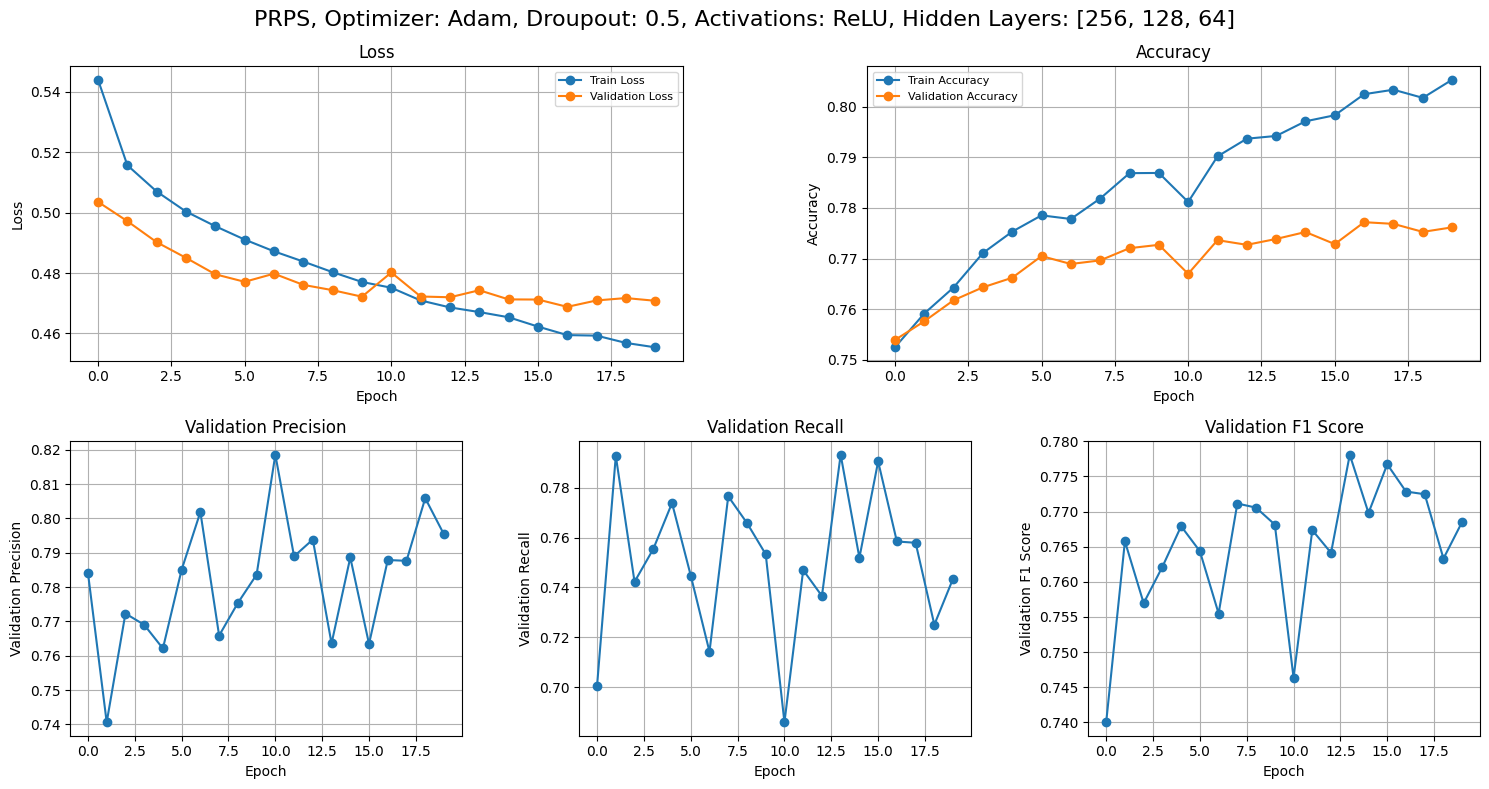

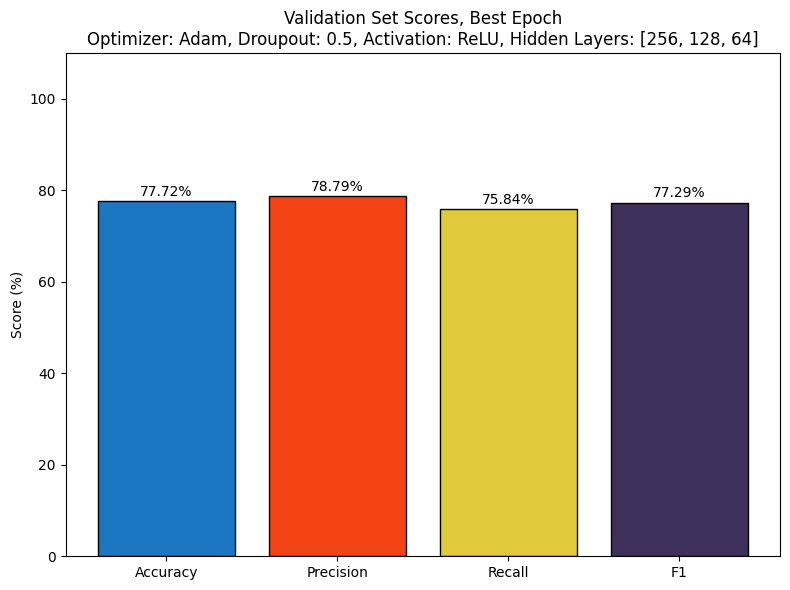

Epoch 1/50 | Train Loss: 0.5394 | Val Loss: 0.5015 | Train Acc: 0.7532 | Val Acc: 0.7548 | Val Precision: 0.7426 | Val Recall: 0.7798 | Val F1: 0.7608
Epoch 2/50 | Train Loss: 0.5133 | Val Loss: 0.4908 | Train Acc: 0.7634 | Val Acc: 0.7613 | Val Precision: 0.7591 | Val Recall: 0.7652 | Val F1: 0.7622
Epoch 3/50 | Train Loss: 0.5041 | Val Loss: 0.4890 | Train Acc: 0.7690 | Val Acc: 0.7650 | Val Precision: 0.7637 | Val Recall: 0.7673 | Val F1: 0.7655
Epoch 4/50 | Train Loss: 0.4971 | Val Loss: 0.4894 | Train Acc: 0.7719 | Val Acc: 0.7659 | Val Precision: 0.7900 | Val Recall: 0.7241 | Val F1: 0.7556
Epoch 5/50 | Train Loss: 0.4916 | Val Loss: 0.4807 | Train Acc: 0.7756 | Val Acc: 0.7677 | Val Precision: 0.7689 | Val Recall: 0.7654 | Val F1: 0.7671
Epoch 6/50 | Train Loss: 0.4871 | Val Loss: 0.4800 | Train Acc: 0.7780 | Val Acc: 0.7675 | Val Precision: 0.7914 | Val Recall: 0.7263 | Val F1: 0.7574
Epoch 7/50 | Train Loss: 0.4836 | Val Loss: 0.4779 | Train Acc: 0.7803 | Val Acc: 0.7704 | Val

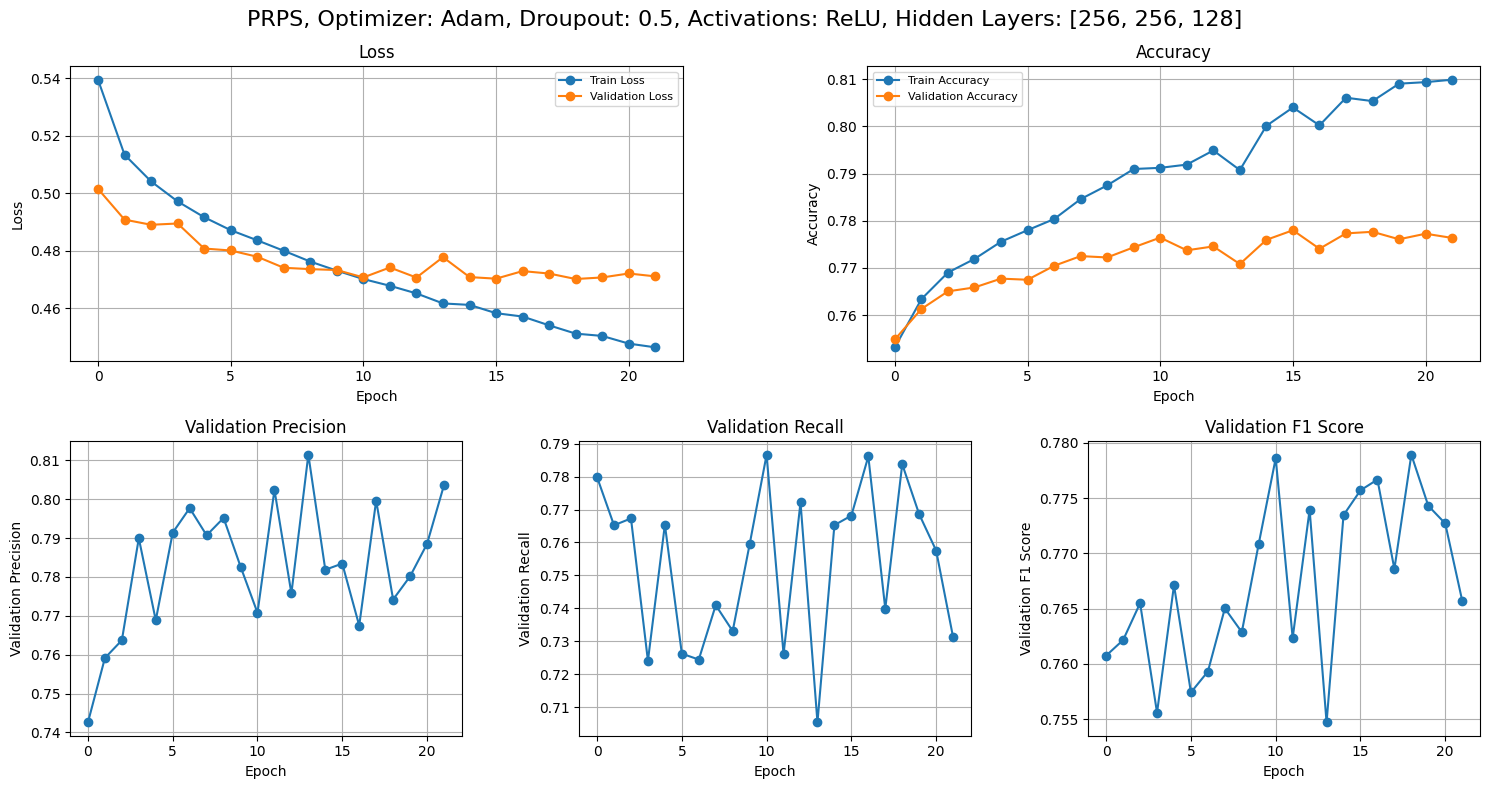

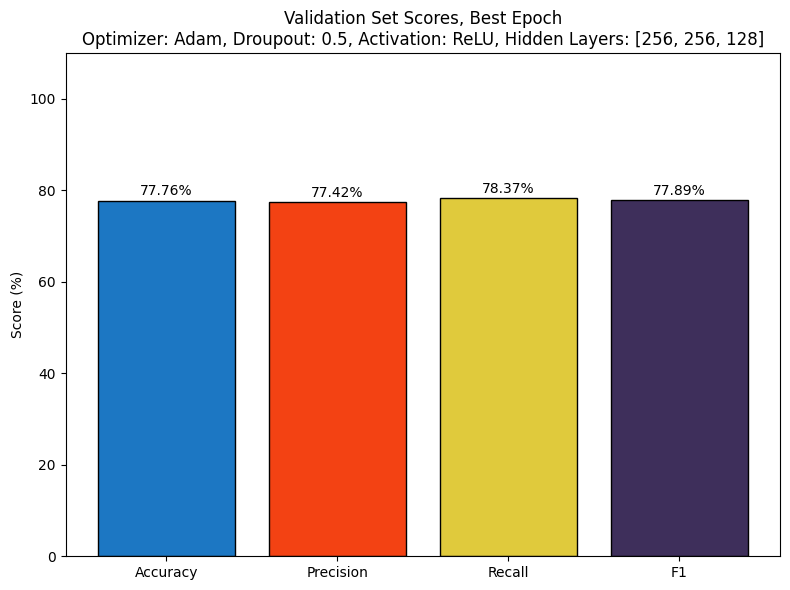

Epoch 1/50 | Train Loss: 0.5368 | Val Loss: 0.5034 | Train Acc: 0.7542 | Val Acc: 0.7567 | Val Precision: 0.7649 | Val Recall: 0.7410 | Val F1: 0.7527
Epoch 2/50 | Train Loss: 0.5120 | Val Loss: 0.4931 | Train Acc: 0.7624 | Val Acc: 0.7613 | Val Precision: 0.7601 | Val Recall: 0.7632 | Val F1: 0.7617
Epoch 3/50 | Train Loss: 0.5015 | Val Loss: 0.4903 | Train Acc: 0.7669 | Val Acc: 0.7606 | Val Precision: 0.7421 | Val Recall: 0.7985 | Val F1: 0.7693
Epoch 4/50 | Train Loss: 0.4952 | Val Loss: 0.4804 | Train Acc: 0.7727 | Val Acc: 0.7678 | Val Precision: 0.7795 | Val Recall: 0.7468 | Val F1: 0.7628
Epoch 5/50 | Train Loss: 0.4882 | Val Loss: 0.4809 | Train Acc: 0.7776 | Val Acc: 0.7665 | Val Precision: 0.7553 | Val Recall: 0.7880 | Val F1: 0.7713
Epoch 6/50 | Train Loss: 0.4830 | Val Loss: 0.4802 | Train Acc: 0.7819 | Val Acc: 0.7713 | Val Precision: 0.7802 | Val Recall: 0.7552 | Val F1: 0.7675
Epoch 7/50 | Train Loss: 0.4786 | Val Loss: 0.4772 | Train Acc: 0.7842 | Val Acc: 0.7713 | Val

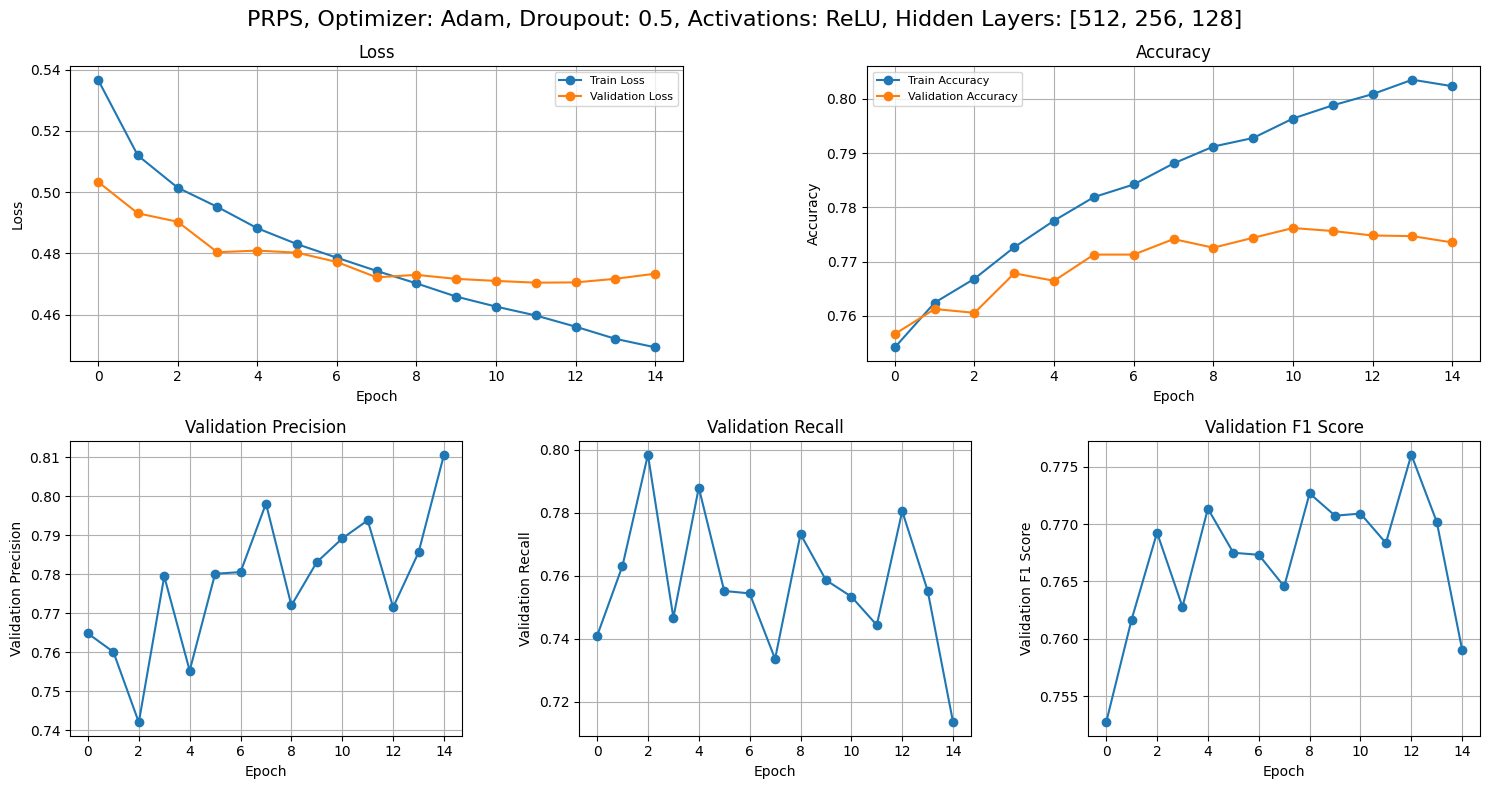

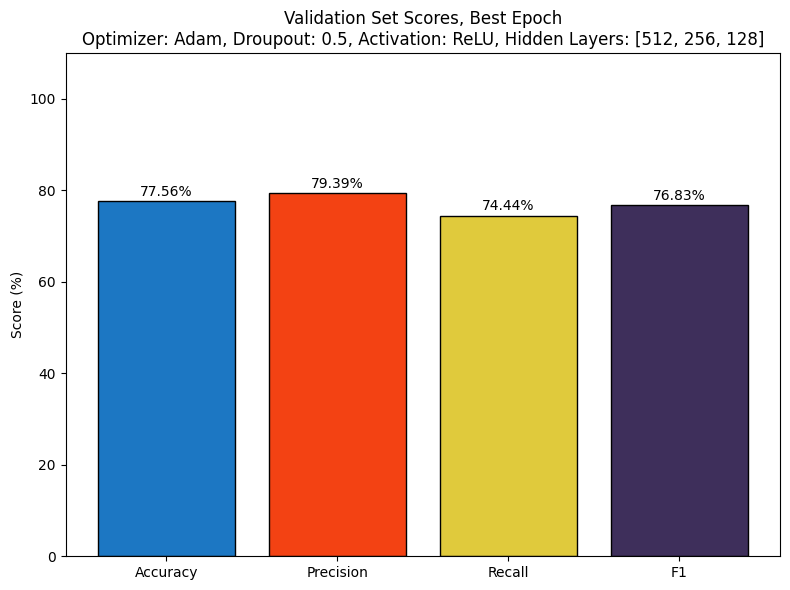

Epoch 1/50 | Train Loss: 0.5566 | Val Loss: 0.5093 | Train Acc: 0.7456 | Val Acc: 0.7482 | Val Precision: 0.7209 | Val Recall: 0.8097 | Val F1: 0.7627
Epoch 2/50 | Train Loss: 0.5275 | Val Loss: 0.5031 | Train Acc: 0.7546 | Val Acc: 0.7549 | Val Precision: 0.7329 | Val Recall: 0.8017 | Val F1: 0.7658
Epoch 3/50 | Train Loss: 0.5195 | Val Loss: 0.4934 | Train Acc: 0.7623 | Val Acc: 0.7613 | Val Precision: 0.7494 | Val Recall: 0.7851 | Val F1: 0.7668
Epoch 4/50 | Train Loss: 0.5143 | Val Loss: 0.4883 | Train Acc: 0.7674 | Val Acc: 0.7648 | Val Precision: 0.7596 | Val Recall: 0.7747 | Val F1: 0.7671
Epoch 5/50 | Train Loss: 0.5088 | Val Loss: 0.4836 | Train Acc: 0.7714 | Val Acc: 0.7654 | Val Precision: 0.7712 | Val Recall: 0.7546 | Val F1: 0.7628
Epoch 6/50 | Train Loss: 0.5052 | Val Loss: 0.4819 | Train Acc: 0.7720 | Val Acc: 0.7674 | Val Precision: 0.7770 | Val Recall: 0.7498 | Val F1: 0.7632
Epoch 7/50 | Train Loss: 0.5034 | Val Loss: 0.4855 | Train Acc: 0.7748 | Val Acc: 0.7670 | Val

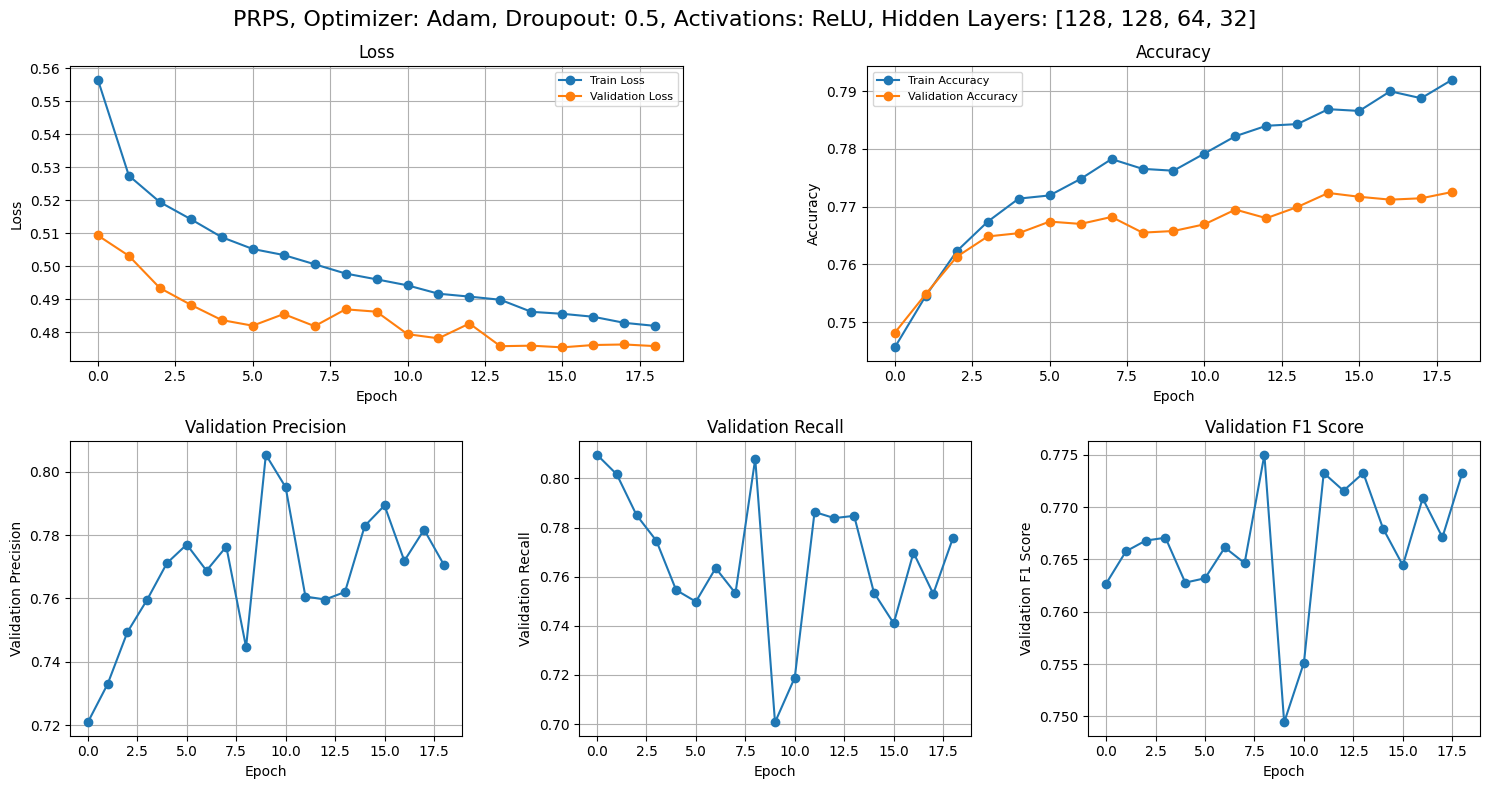

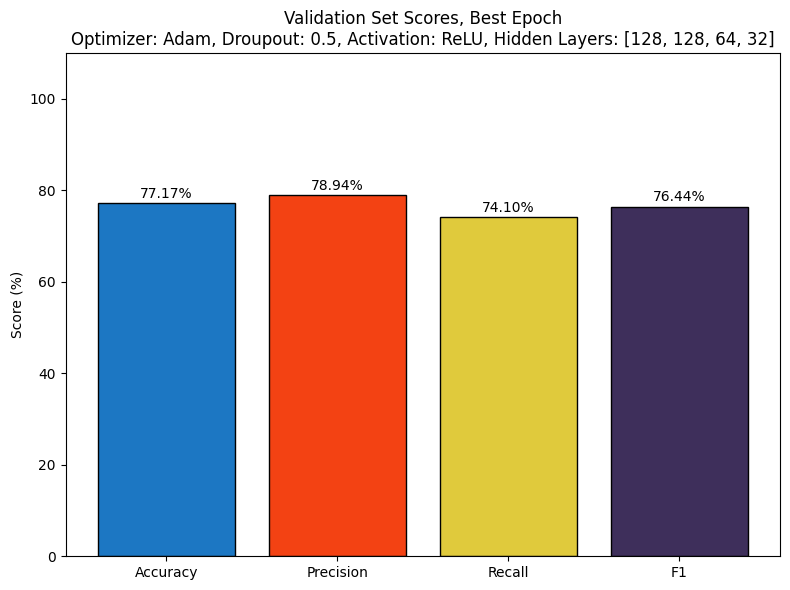

Epoch 1/50 | Train Loss: 0.5537 | Val Loss: 0.5039 | Train Acc: 0.7509 | Val Acc: 0.7524 | Val Precision: 0.7896 | Val Recall: 0.6880 | Val F1: 0.7353
Epoch 2/50 | Train Loss: 0.5241 | Val Loss: 0.4952 | Train Acc: 0.7602 | Val Acc: 0.7580 | Val Precision: 0.7529 | Val Recall: 0.7680 | Val F1: 0.7604
Epoch 3/50 | Train Loss: 0.5160 | Val Loss: 0.4890 | Train Acc: 0.7650 | Val Acc: 0.7632 | Val Precision: 0.7539 | Val Recall: 0.7811 | Val F1: 0.7673
Epoch 4/50 | Train Loss: 0.5095 | Val Loss: 0.4847 | Train Acc: 0.7704 | Val Acc: 0.7658 | Val Precision: 0.7664 | Val Recall: 0.7645 | Val F1: 0.7655
Epoch 5/50 | Train Loss: 0.5057 | Val Loss: 0.4832 | Train Acc: 0.7713 | Val Acc: 0.7655 | Val Precision: 0.7587 | Val Recall: 0.7785 | Val F1: 0.7685
Epoch 6/50 | Train Loss: 0.5014 | Val Loss: 0.4903 | Train Acc: 0.7684 | Val Acc: 0.7599 | Val Precision: 0.7346 | Val Recall: 0.8133 | Val F1: 0.7720
Epoch 7/50 | Train Loss: 0.4969 | Val Loss: 0.4818 | Train Acc: 0.7768 | Val Acc: 0.7690 | Val

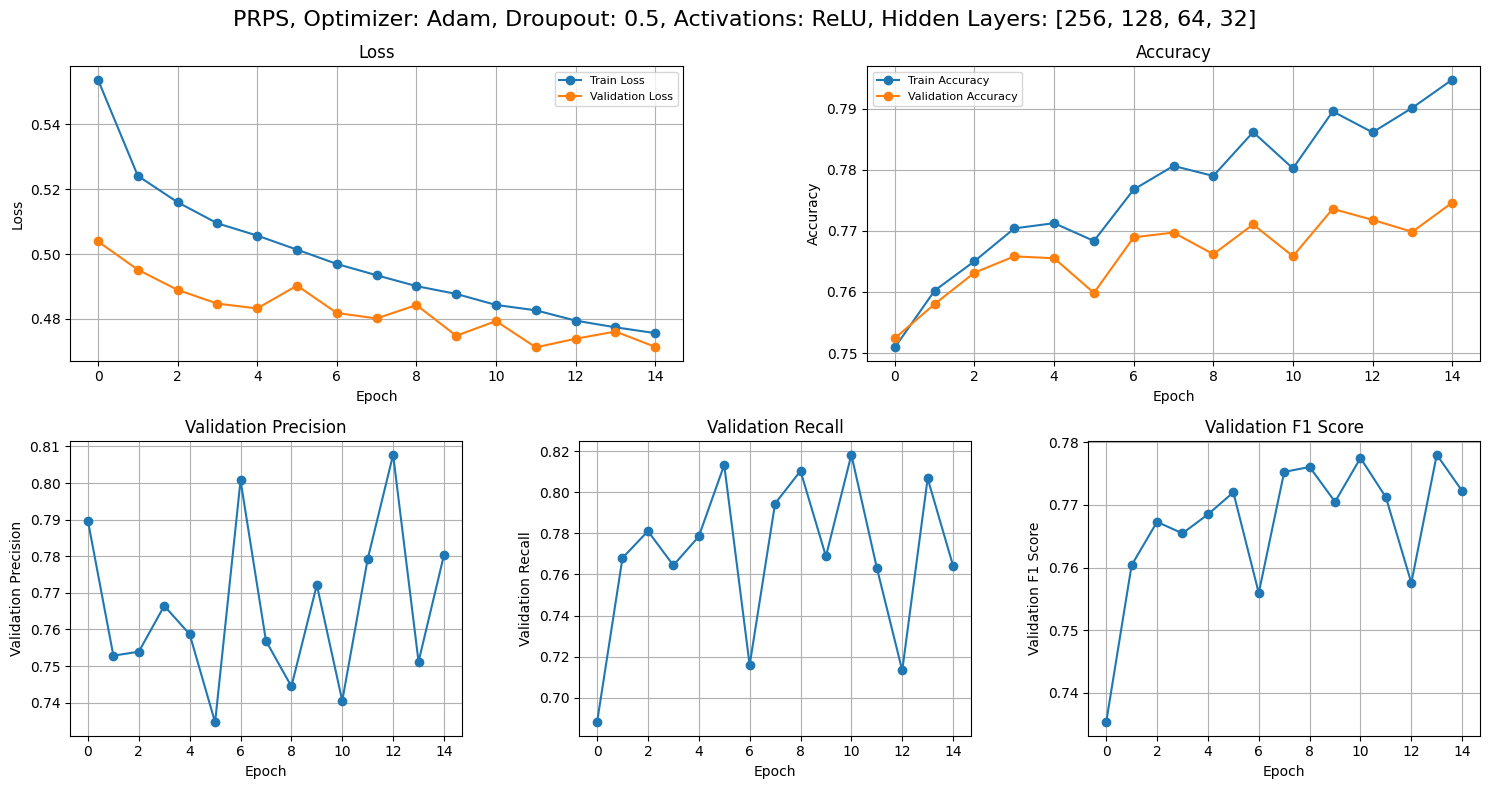

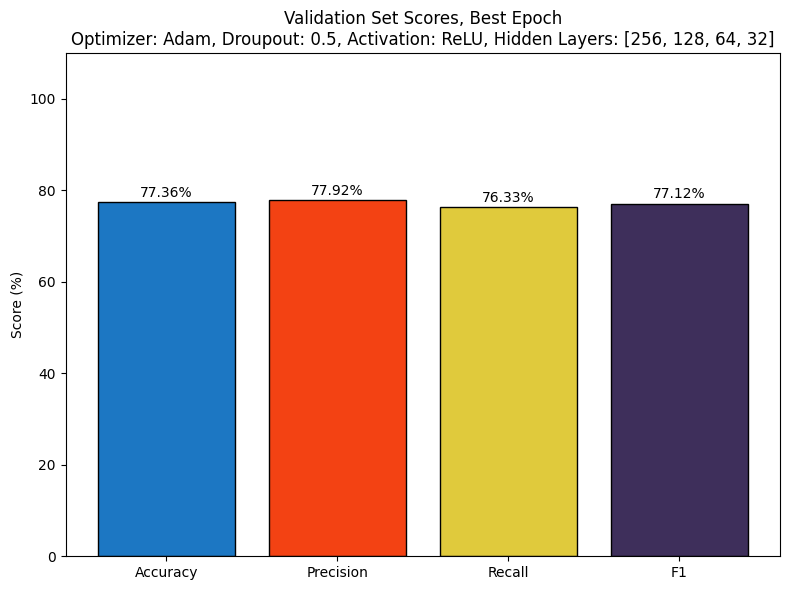

Epoch 1/50 | Train Loss: 0.5467 | Val Loss: 0.5137 | Train Acc: 0.7383 | Val Acc: 0.7402 | Val Precision: 0.8228 | Val Recall: 0.6121 | Val F1: 0.7020
Epoch 2/50 | Train Loss: 0.5183 | Val Loss: 0.5079 | Train Acc: 0.7456 | Val Acc: 0.7465 | Val Precision: 0.7054 | Val Recall: 0.8463 | Val F1: 0.7694
Epoch 3/50 | Train Loss: 0.5093 | Val Loss: 0.4921 | Train Acc: 0.7649 | Val Acc: 0.7614 | Val Precision: 0.7801 | Val Recall: 0.7277 | Val F1: 0.7530
Epoch 4/50 | Train Loss: 0.5023 | Val Loss: 0.4991 | Train Acc: 0.7583 | Val Acc: 0.7514 | Val Precision: 0.7156 | Val Recall: 0.8342 | Val F1: 0.7704
Epoch 5/50 | Train Loss: 0.4980 | Val Loss: 0.4835 | Train Acc: 0.7749 | Val Acc: 0.7654 | Val Precision: 0.7946 | Val Recall: 0.7156 | Val F1: 0.7530
Epoch 6/50 | Train Loss: 0.4936 | Val Loss: 0.4784 | Train Acc: 0.7782 | Val Acc: 0.7688 | Val Precision: 0.7686 | Val Recall: 0.7689 | Val F1: 0.7688
Epoch 7/50 | Train Loss: 0.4893 | Val Loss: 0.4848 | Train Acc: 0.7729 | Val Acc: 0.7618 | Val

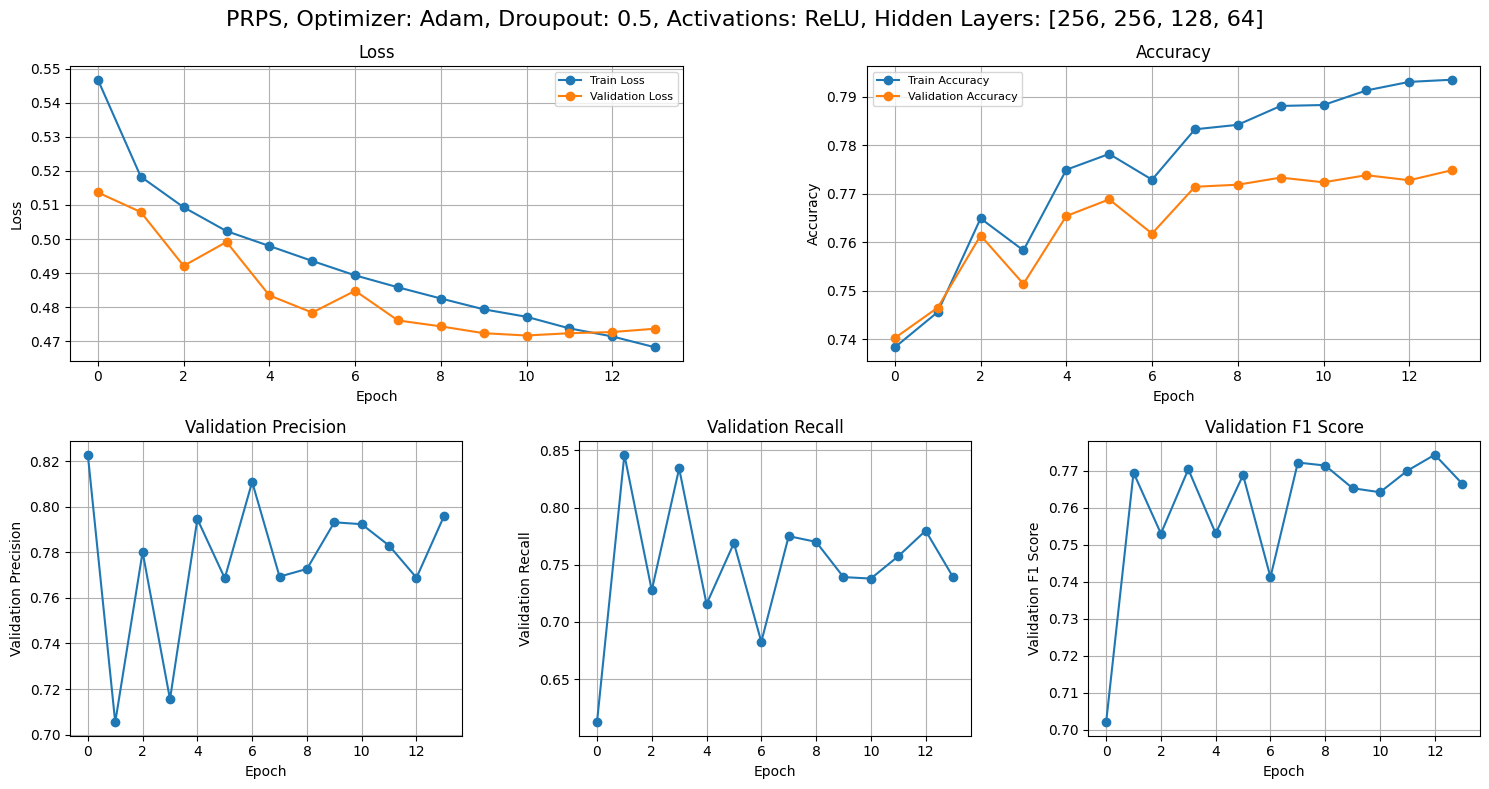

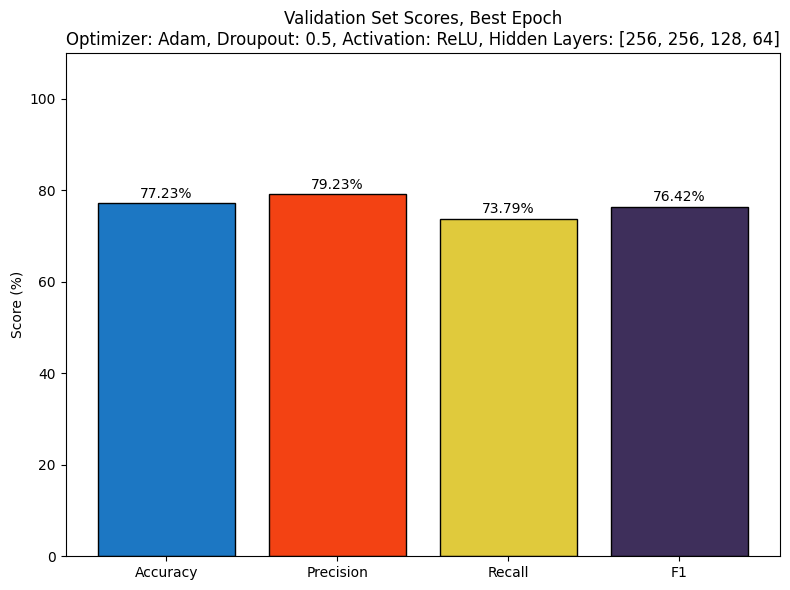

Epoch 1/50 | Train Loss: 0.5436 | Val Loss: 0.5172 | Train Acc: 0.7460 | Val Acc: 0.7482 | Val Precision: 0.7229 | Val Recall: 0.8047 | Val F1: 0.7616
Epoch 2/50 | Train Loss: 0.5153 | Val Loss: 0.4988 | Train Acc: 0.7565 | Val Acc: 0.7573 | Val Precision: 0.8125 | Val Recall: 0.6686 | Val F1: 0.7336
Epoch 3/50 | Train Loss: 0.5073 | Val Loss: 0.4852 | Train Acc: 0.7689 | Val Acc: 0.7648 | Val Precision: 0.7684 | Val Recall: 0.7578 | Val F1: 0.7631
Epoch 4/50 | Train Loss: 0.4991 | Val Loss: 0.4850 | Train Acc: 0.7688 | Val Acc: 0.7642 | Val Precision: 0.8078 | Val Recall: 0.6931 | Val F1: 0.7461
Epoch 5/50 | Train Loss: 0.4935 | Val Loss: 0.4861 | Train Acc: 0.7700 | Val Acc: 0.7635 | Val Precision: 0.7413 | Val Recall: 0.8092 | Val F1: 0.7738
Epoch 6/50 | Train Loss: 0.4886 | Val Loss: 0.4754 | Train Acc: 0.7821 | Val Acc: 0.7722 | Val Precision: 0.7818 | Val Recall: 0.7550 | Val F1: 0.7682
Epoch 7/50 | Train Loss: 0.4852 | Val Loss: 0.4769 | Train Acc: 0.7835 | Val Acc: 0.7702 | Val

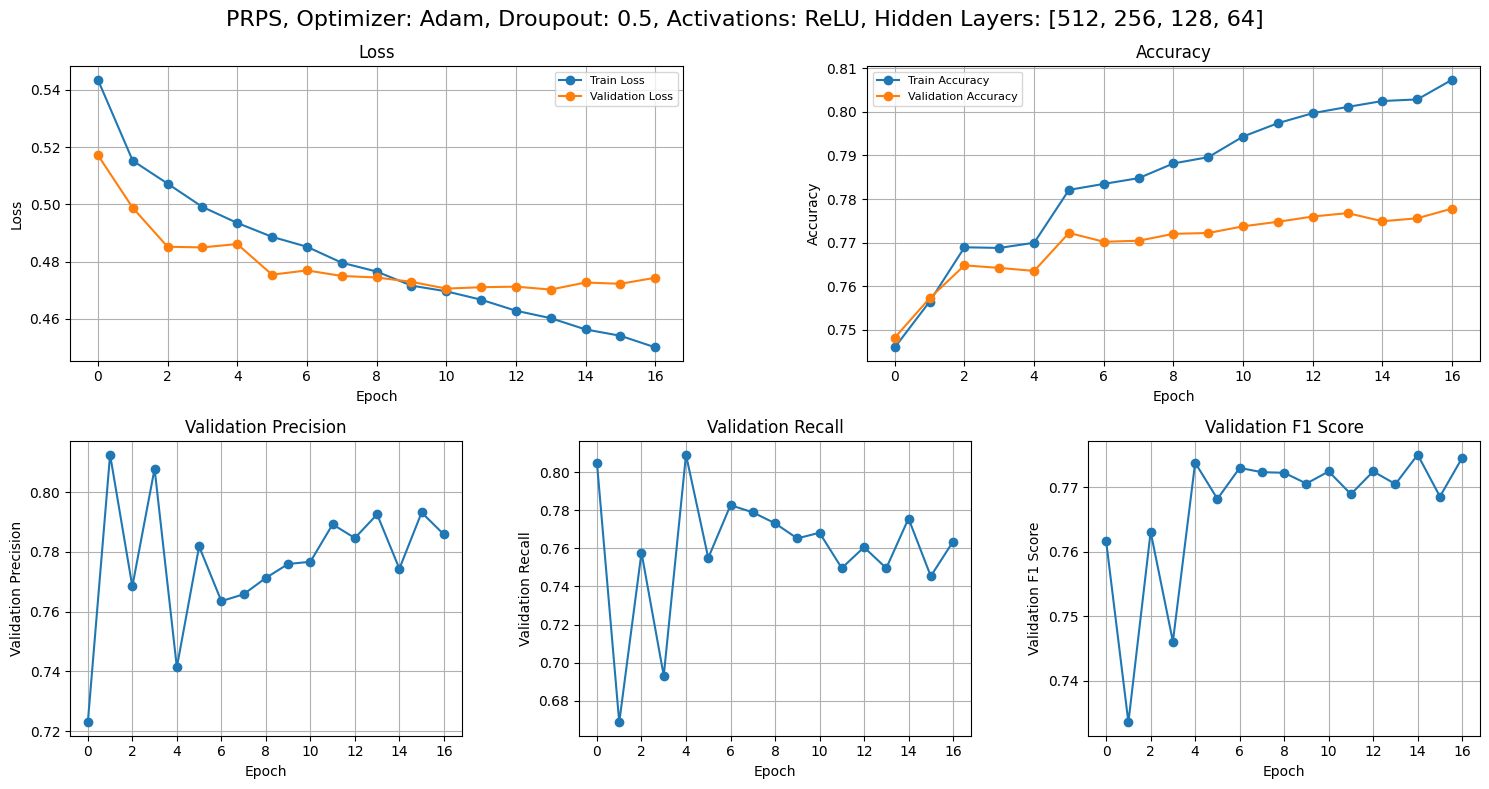

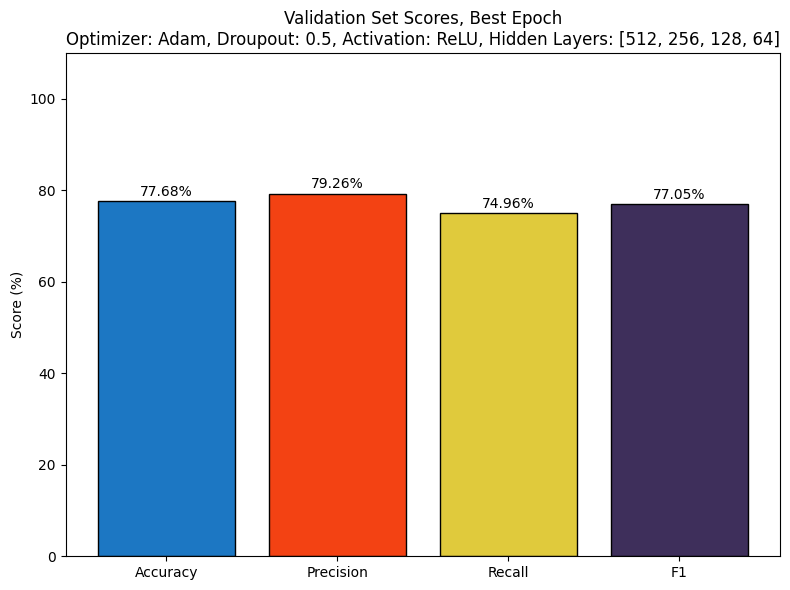

In [79]:
results_list = []

for nn_config in nn_configs_list:
    
    model = NeuralNet(**nn_config).to(device)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    results = train_model(
        model, 
        train_loader, 
        val_loader, 
        loss_fn, 
        optimizer, 
        n_epochs=50,
        device=device,
        early=True,
    )

    results_list.append((nn_config, results))

    plot_epochs_scores(results, f"PRPS, Optimizer: Adam, Droupout: {nn_config['dropout']}, Activations: ReLU, Hidden Layers: {nn_config['hidden_sizes']}")
    plot_best_scores(results, f"Validation Set Scores, Best Epoch\nOptimizer: Adam, Droupout: {nn_config['dropout']}, Activation: ReLU, Hidden Layers: {nn_config['hidden_sizes']}")

In [80]:
best_nn_conf, best_scores = get_best_results(results_list)

### After determining the best hidden layer configuration, we experiment with the following optimizers based on validation set accuracy
- NAdam
- AdamW
- SGD
- RMSprop

In [81]:
optimizers = {
    torch.optim.NAdam: "NAdam",
    torch.optim.AdamW: "AdamW",
    torch.optim.SGD: "SGD",
    torch.optim.RMSprop: "RMSprop"
}

### The result list is initialized with Adam since it has already been evaluated. We further investigate other optimizer functions and compare the results

Epoch 1/50 | Train Loss: 0.5423 | Val Loss: 0.5230 | Train Acc: 0.7387 | Val Acc: 0.7404 | Val Precision: 0.6988 | Val Recall: 0.8448 | Val F1: 0.7649
Epoch 2/50 | Train Loss: 0.5197 | Val Loss: 0.4950 | Train Acc: 0.7600 | Val Acc: 0.7586 | Val Precision: 0.7535 | Val Recall: 0.7683 | Val F1: 0.7608
Epoch 3/50 | Train Loss: 0.5119 | Val Loss: 0.4898 | Train Acc: 0.7652 | Val Acc: 0.7625 | Val Precision: 0.7609 | Val Recall: 0.7654 | Val F1: 0.7631
Epoch 4/50 | Train Loss: 0.5065 | Val Loss: 0.4870 | Train Acc: 0.7690 | Val Acc: 0.7627 | Val Precision: 0.7827 | Val Recall: 0.7271 | Val F1: 0.7539
Epoch 5/50 | Train Loss: 0.5037 | Val Loss: 0.4833 | Train Acc: 0.7723 | Val Acc: 0.7678 | Val Precision: 0.7774 | Val Recall: 0.7504 | Val F1: 0.7636
Epoch 6/50 | Train Loss: 0.4995 | Val Loss: 0.4827 | Train Acc: 0.7747 | Val Acc: 0.7658 | Val Precision: 0.7559 | Val Recall: 0.7849 | Val F1: 0.7701
Epoch 7/50 | Train Loss: 0.4975 | Val Loss: 0.4818 | Train Acc: 0.7758 | Val Acc: 0.7677 | Val

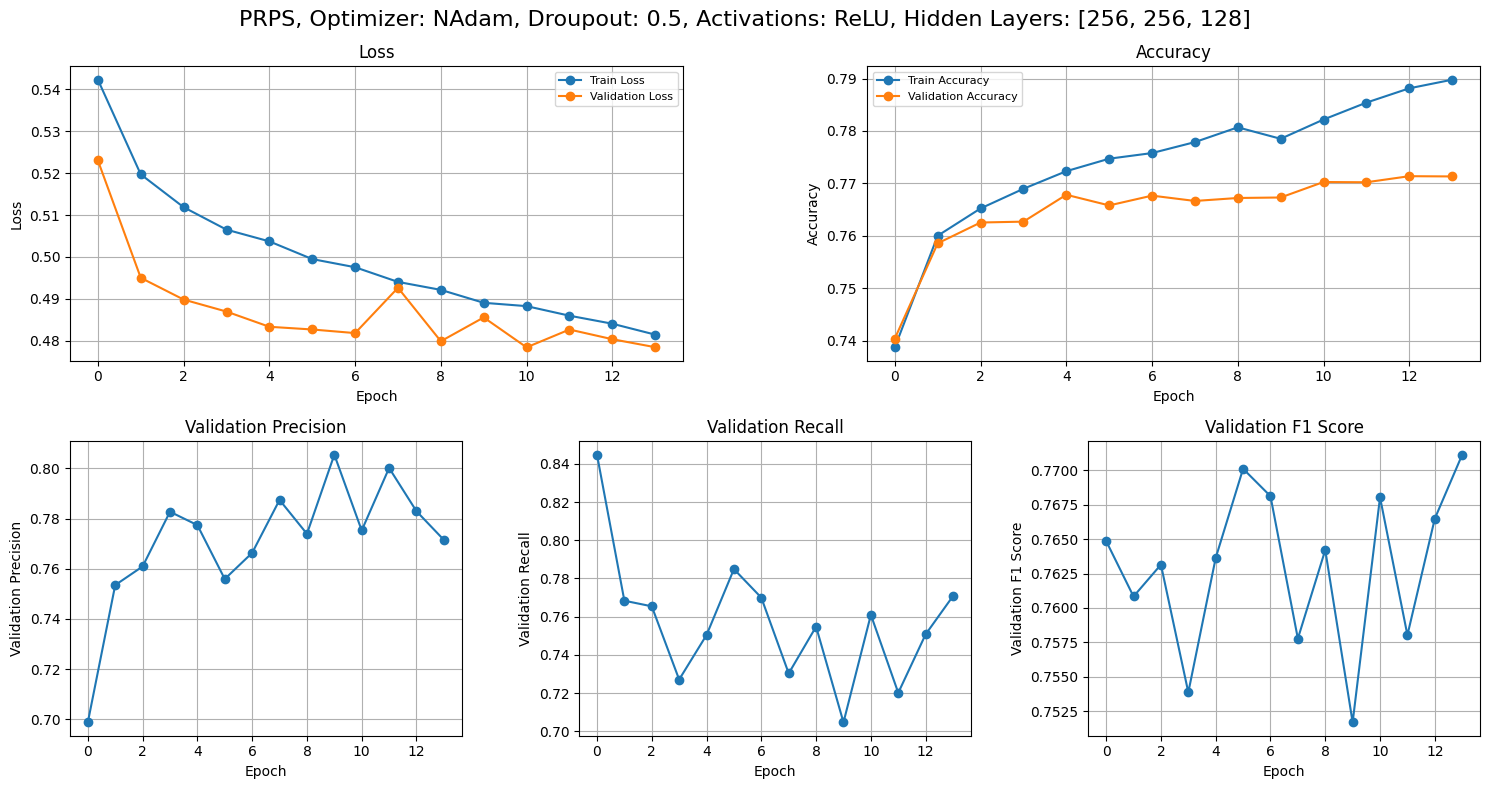

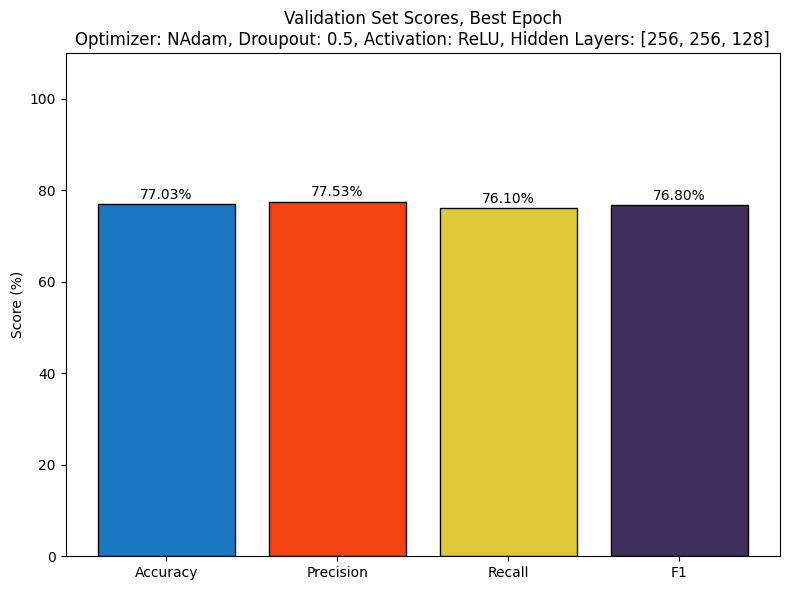

Epoch 1/50 | Train Loss: 0.5432 | Val Loss: 0.5064 | Train Acc: 0.7535 | Val Acc: 0.7549 | Val Precision: 0.7555 | Val Recall: 0.7536 | Val F1: 0.7546
Epoch 2/50 | Train Loss: 0.5232 | Val Loss: 0.4985 | Train Acc: 0.7588 | Val Acc: 0.7589 | Val Precision: 0.7541 | Val Recall: 0.7681 | Val F1: 0.7610
Epoch 3/50 | Train Loss: 0.5170 | Val Loss: 0.4925 | Train Acc: 0.7651 | Val Acc: 0.7622 | Val Precision: 0.7705 | Val Recall: 0.7467 | Val F1: 0.7584
Epoch 4/50 | Train Loss: 0.5122 | Val Loss: 0.4900 | Train Acc: 0.7666 | Val Acc: 0.7637 | Val Precision: 0.7593 | Val Recall: 0.7719 | Val F1: 0.7656
Epoch 5/50 | Train Loss: 0.5075 | Val Loss: 0.4884 | Train Acc: 0.7697 | Val Acc: 0.7656 | Val Precision: 0.7846 | Val Recall: 0.7321 | Val F1: 0.7574
Epoch 6/50 | Train Loss: 0.5041 | Val Loss: 0.4906 | Train Acc: 0.7717 | Val Acc: 0.7659 | Val Precision: 0.7856 | Val Recall: 0.7313 | Val F1: 0.7574
Epoch 7/50 | Train Loss: 0.5034 | Val Loss: 0.4848 | Train Acc: 0.7712 | Val Acc: 0.7638 | Val

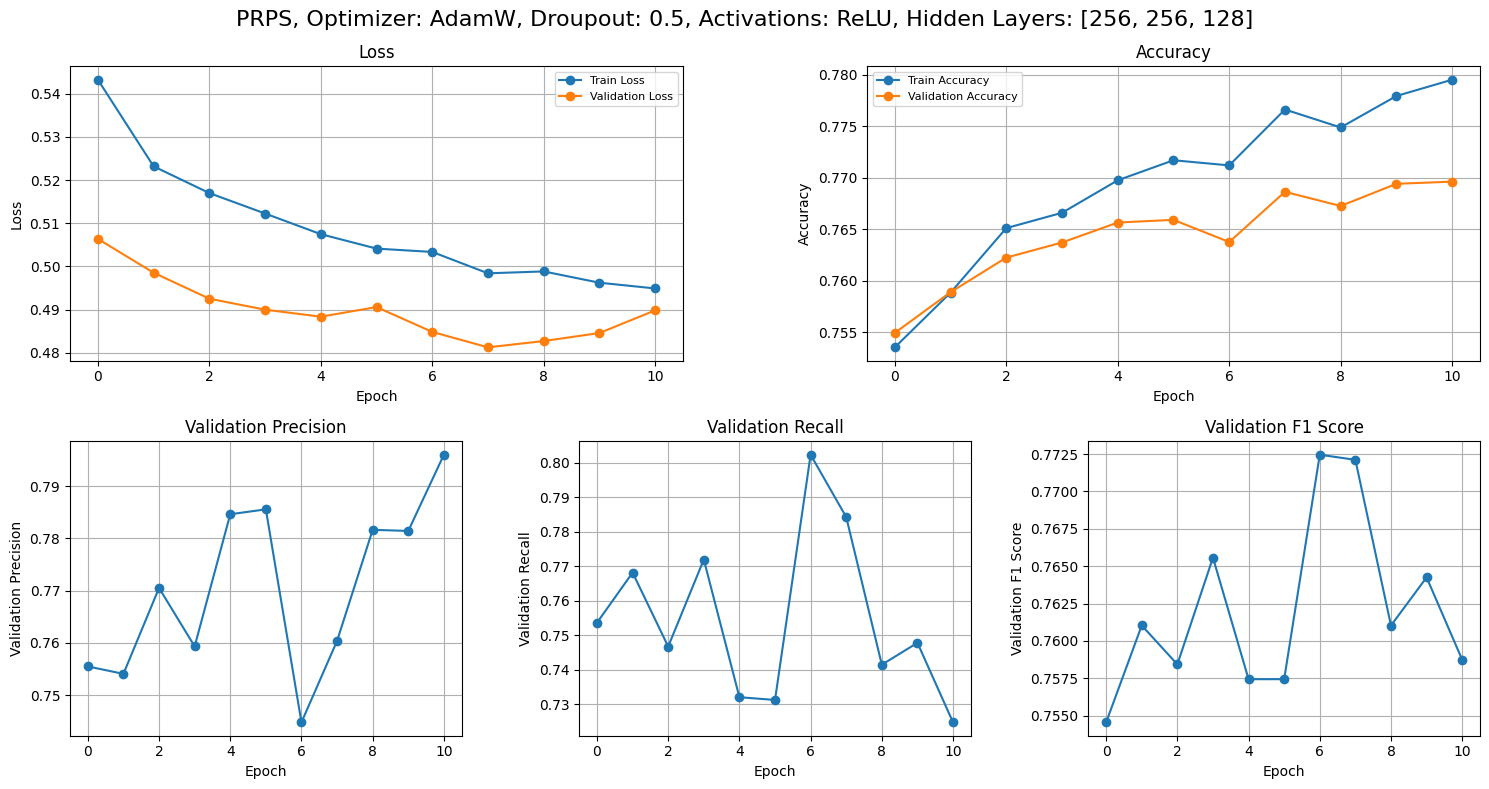

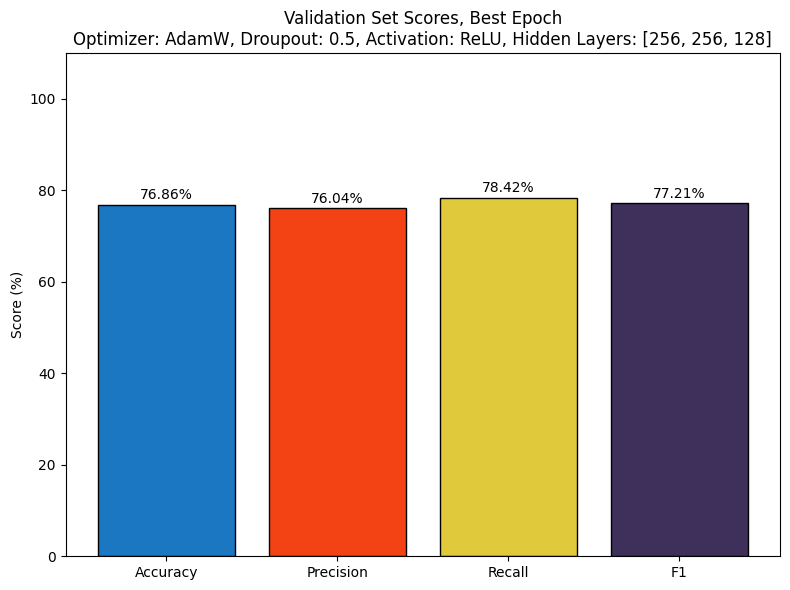

Epoch 1/50 | Train Loss: 0.6933 | Val Loss: 0.6932 | Train Acc: 0.4989 | Val Acc: 0.4986 | Val Precision: 0.4992 | Val Recall: 0.9962 | Val F1: 0.6651
Epoch 2/50 | Train Loss: 0.6932 | Val Loss: 0.6932 | Train Acc: 0.4854 | Val Acc: 0.4814 | Val Precision: 0.4898 | Val Recall: 0.9034 | Val F1: 0.6352
Epoch 3/50 | Train Loss: 0.6932 | Val Loss: 0.6932 | Train Acc: 0.4836 | Val Acc: 0.4803 | Val Precision: 0.4815 | Val Recall: 0.5176 | Val F1: 0.4989
Epoch 4/50 | Train Loss: 0.6932 | Val Loss: 0.6931 | Train Acc: 0.5117 | Val Acc: 0.5116 | Val Precision: 0.5799 | Val Recall: 0.0827 | Val F1: 0.1448
Epoch 5/50 | Train Loss: 0.6931 | Val Loss: 0.6931 | Train Acc: 0.5088 | Val Acc: 0.5093 | Val Precision: 0.7055 | Val Recall: 0.0315 | Val F1: 0.0603
Epoch 6/50 | Train Loss: 0.6931 | Val Loss: 0.6931 | Train Acc: 0.5067 | Val Acc: 0.5068 | Val Precision: 0.7945 | Val Recall: 0.0179 | Val F1: 0.0350
Epoch 7/50 | Train Loss: 0.6931 | Val Loss: 0.6930 | Train Acc: 0.5326 | Val Acc: 0.5328 | Val

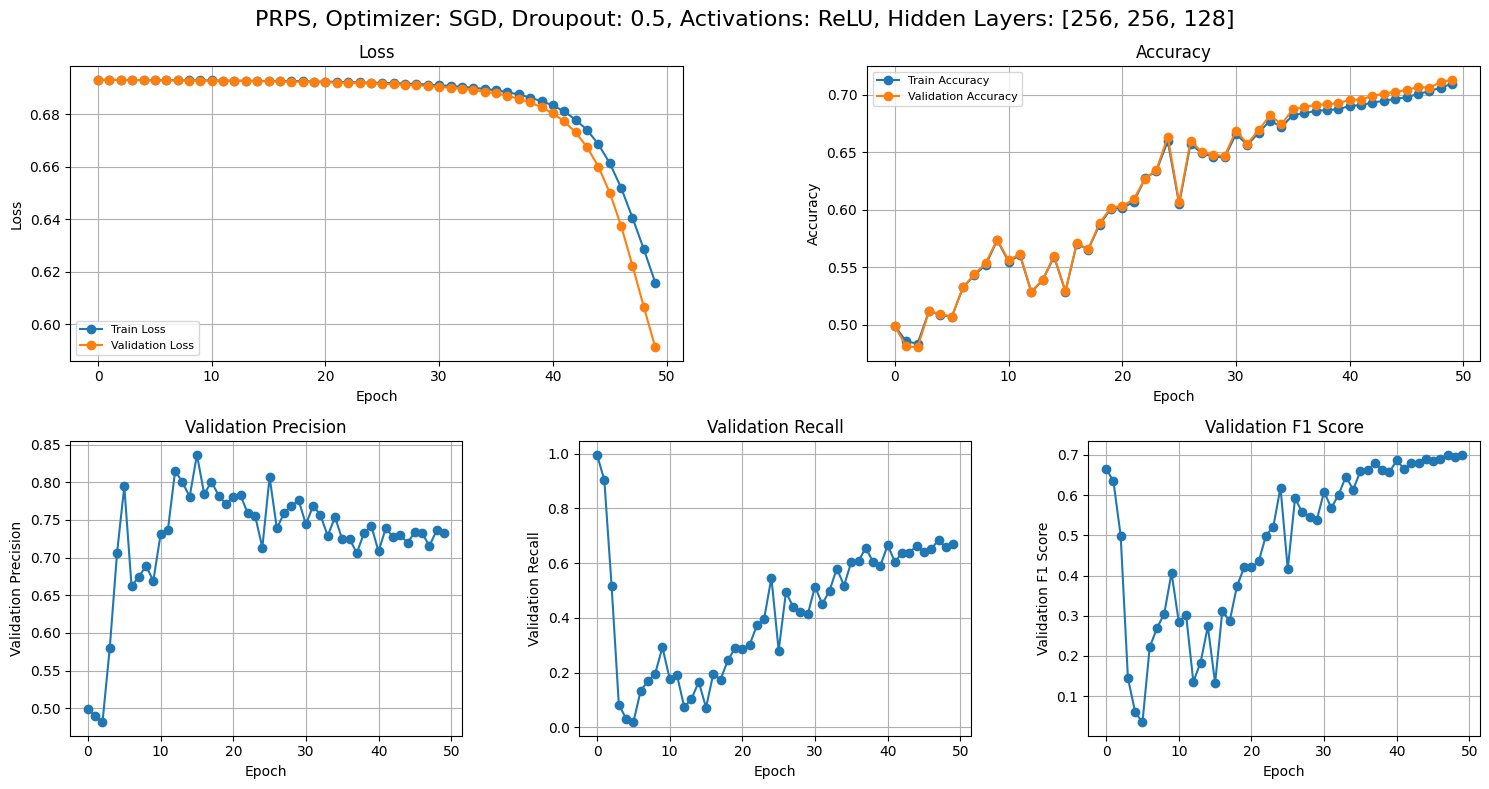

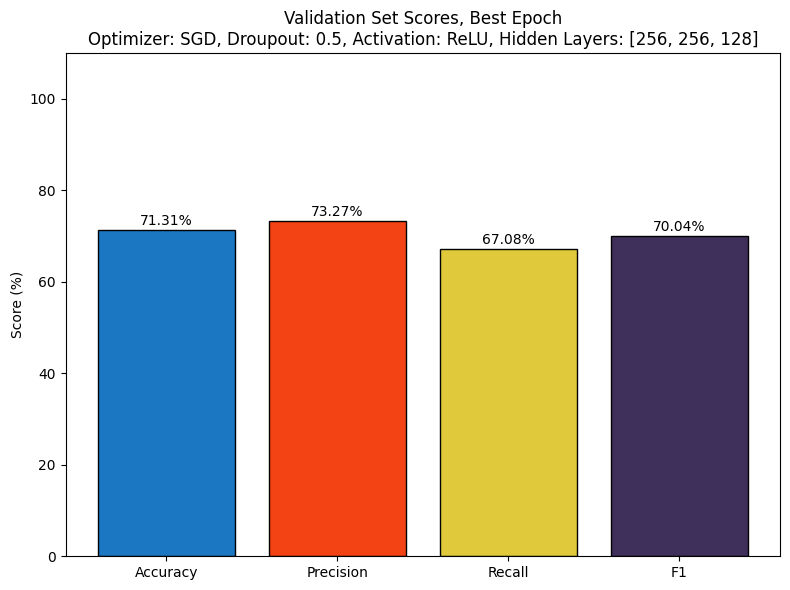

Epoch 1/50 | Train Loss: 0.5508 | Val Loss: 0.5060 | Train Acc: 0.7487 | Val Acc: 0.7513 | Val Precision: 0.7294 | Val Recall: 0.7988 | Val F1: 0.7625
Epoch 2/50 | Train Loss: 0.5273 | Val Loss: 0.5072 | Train Acc: 0.7607 | Val Acc: 0.7600 | Val Precision: 0.7608 | Val Recall: 0.7582 | Val F1: 0.7595
Epoch 3/50 | Train Loss: 0.5182 | Val Loss: 0.4936 | Train Acc: 0.7614 | Val Acc: 0.7604 | Val Precision: 0.7466 | Val Recall: 0.7882 | Val F1: 0.7668
Epoch 4/50 | Train Loss: 0.5144 | Val Loss: 0.4889 | Train Acc: 0.7683 | Val Acc: 0.7645 | Val Precision: 0.7749 | Val Recall: 0.7454 | Val F1: 0.7599
Epoch 5/50 | Train Loss: 0.5094 | Val Loss: 0.4894 | Train Acc: 0.7711 | Val Acc: 0.7644 | Val Precision: 0.7691 | Val Recall: 0.7553 | Val F1: 0.7622
Epoch 6/50 | Train Loss: 0.5062 | Val Loss: 0.4830 | Train Acc: 0.7731 | Val Acc: 0.7678 | Val Precision: 0.7795 | Val Recall: 0.7467 | Val F1: 0.7628
Epoch 7/50 | Train Loss: 0.5033 | Val Loss: 0.5025 | Train Acc: 0.7749 | Val Acc: 0.7650 | Val

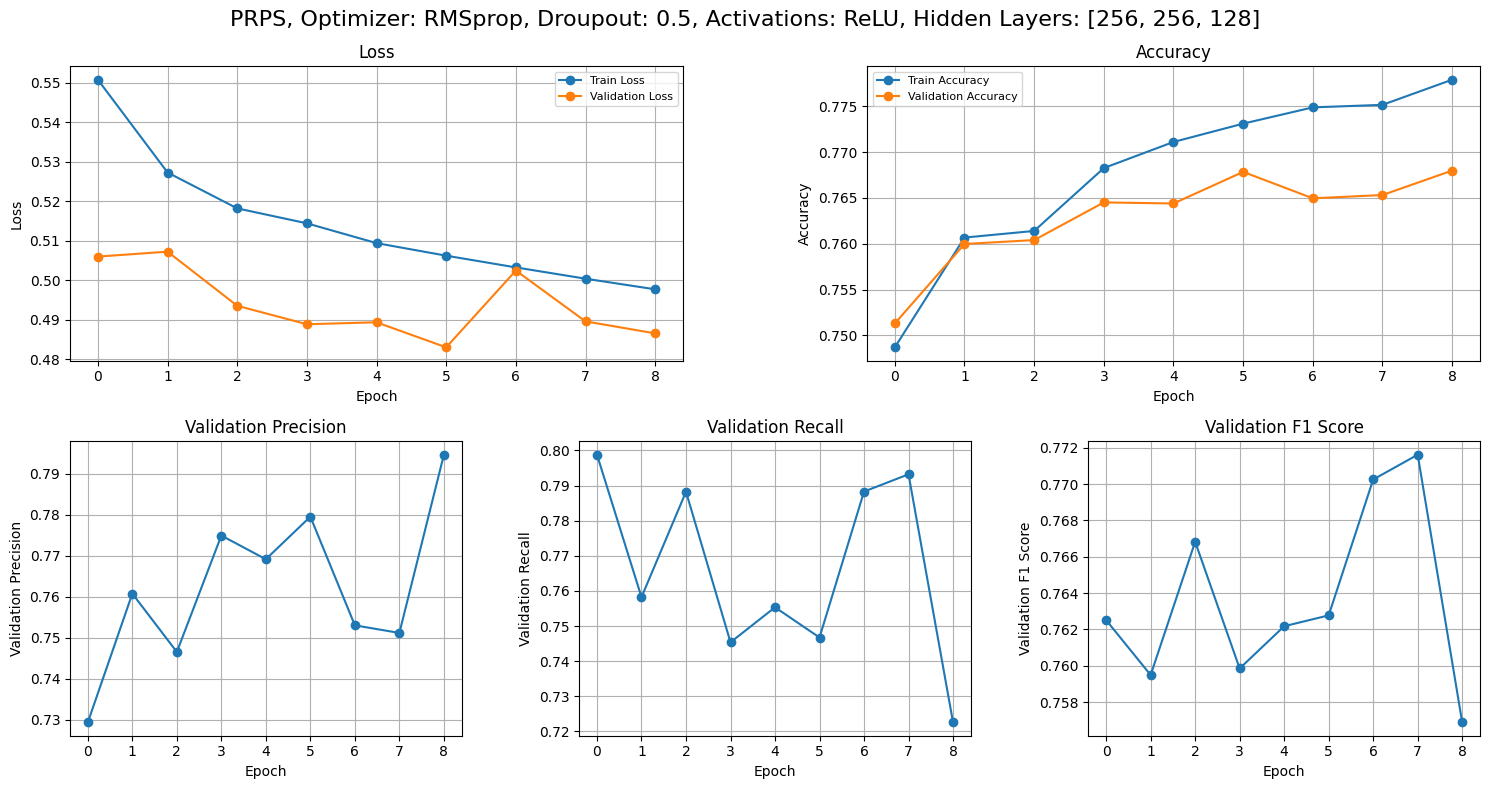

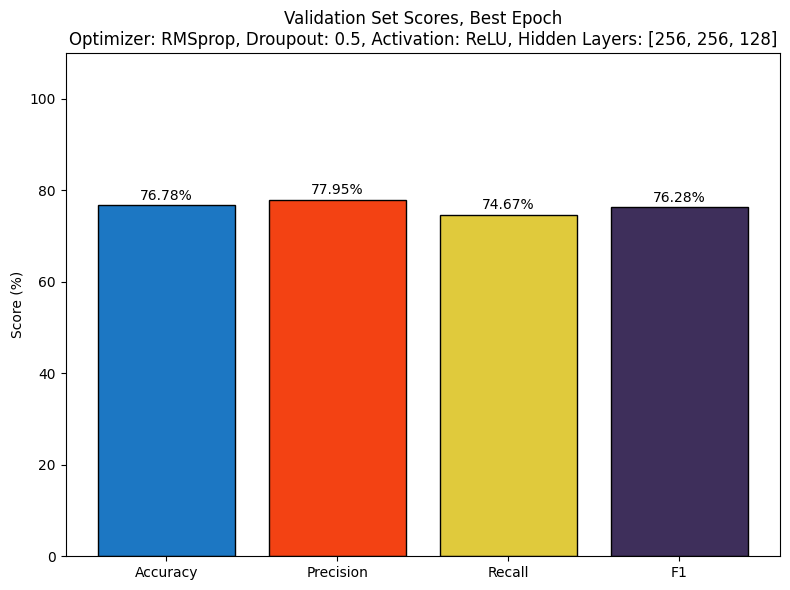

In [82]:
results_list2 = [((torch.optim.Adam, "Adam"), best_scores)]

for optimizer_func, optimizer_name in optimizers.items():
    
    model = NeuralNet(**best_nn_conf).to(device)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    optimizer = optimizer_func(model.parameters(), lr=3e-3)

    results = train_model(
        model, 
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        n_epochs=50,
        device=device,
        early=True
    )

    results_list2.append(((optimizer_func, optimizer_name), results))
    
    plot_epochs_scores(results, f"PRPS, Optimizer: {optimizer_name}, Droupout: {best_nn_conf['dropout']}, Activations: ReLU, Hidden Layers: {best_nn_conf['hidden_sizes']}")
    plot_best_scores(results, f"Validation Set Scores, Best Epoch\nOptimizer: {optimizer_name}, Droupout: {best_nn_conf['dropout']}, Activation: ReLU, Hidden Layers: {best_nn_conf['hidden_sizes']}")

In [83]:
best_optimizer, best_scores = get_best_results(results_list2)
best_optimizer_func, best_optimizer_name = best_optimizer

### Using the best optimizer, we experiment with batch normalization on each hidden layer of the model to improve training performance and validation set accuracy

Epoch 1/50 | Train Loss: 0.5276 | Val Loss: 0.4923 | Train Acc: 0.7638 | Val Acc: 0.7614 | Val Precision: 0.7884 | Val Recall: 0.7145 | Val F1: 0.7496
Epoch 2/50 | Train Loss: 0.5038 | Val Loss: 0.4874 | Train Acc: 0.7696 | Val Acc: 0.7637 | Val Precision: 0.7765 | Val Recall: 0.7403 | Val F1: 0.7580
Epoch 3/50 | Train Loss: 0.4959 | Val Loss: 0.4763 | Train Acc: 0.7785 | Val Acc: 0.7698 | Val Precision: 0.7743 | Val Recall: 0.7614 | Val F1: 0.7678
Epoch 4/50 | Train Loss: 0.4880 | Val Loss: 0.4768 | Train Acc: 0.7809 | Val Acc: 0.7710 | Val Precision: 0.7888 | Val Recall: 0.7398 | Val F1: 0.7635
Epoch 5/50 | Train Loss: 0.4821 | Val Loss: 0.4713 | Train Acc: 0.7870 | Val Acc: 0.7741 | Val Precision: 0.7901 | Val Recall: 0.7463 | Val F1: 0.7676
Epoch 6/50 | Train Loss: 0.4774 | Val Loss: 0.4685 | Train Acc: 0.7900 | Val Acc: 0.7755 | Val Precision: 0.7828 | Val Recall: 0.7624 | Val F1: 0.7725
Epoch 7/50 | Train Loss: 0.4735 | Val Loss: 0.4667 | Train Acc: 0.7945 | Val Acc: 0.7764 | Val

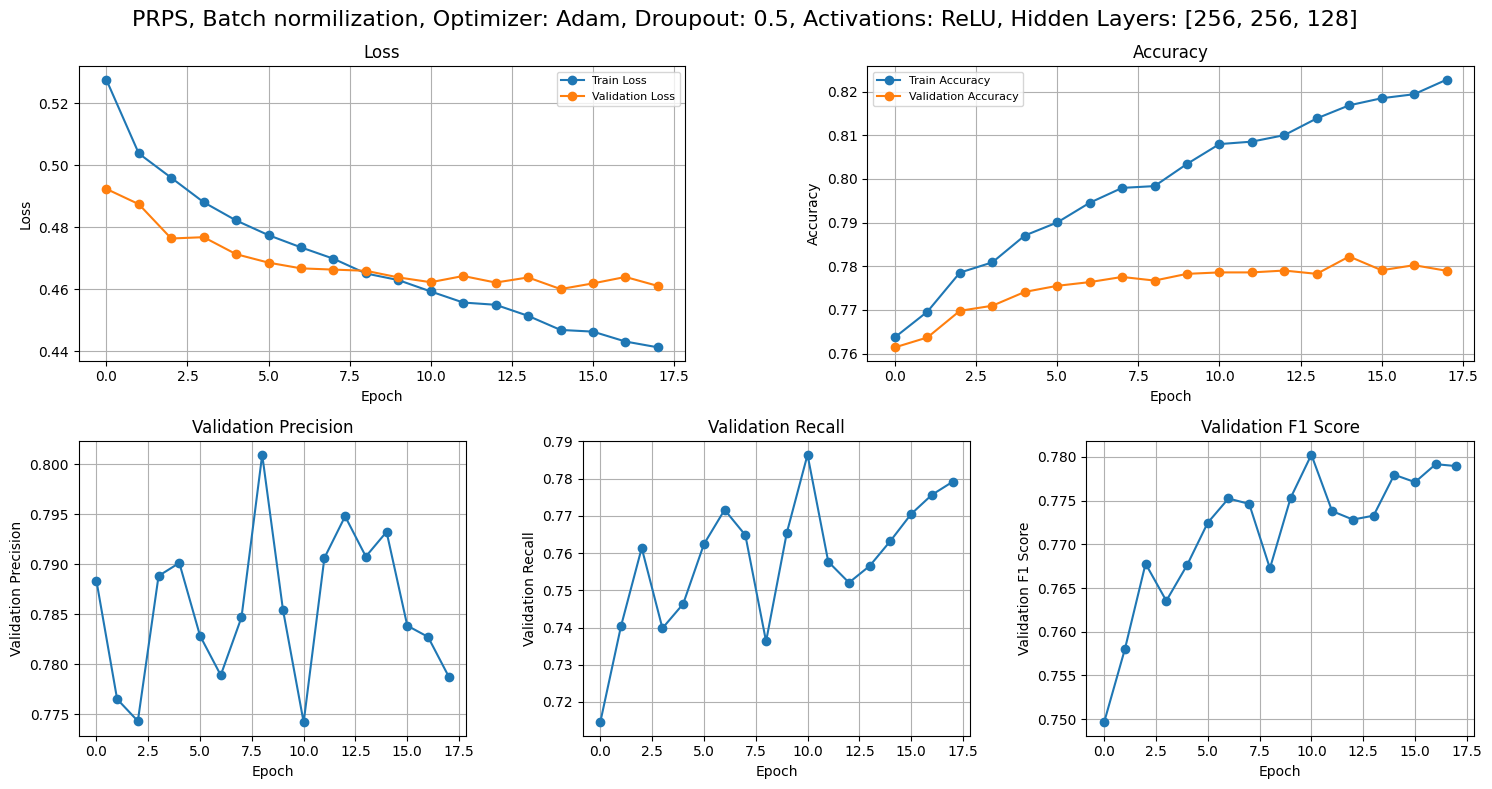

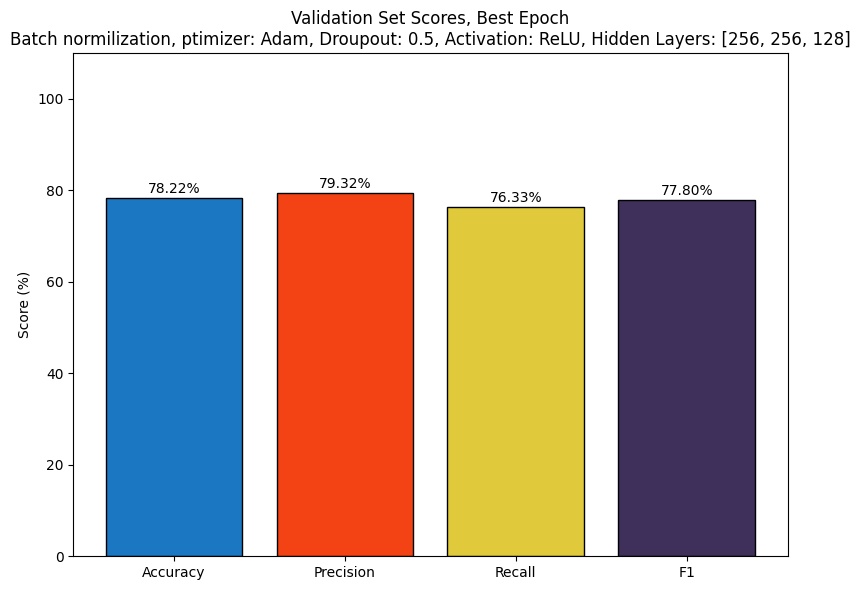

In [84]:
model = NeuralNet(**best_nn_conf, enable_batch_norm=True).to(device)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = best_optimizer_func(model.parameters(), lr=3e-3)

results = train_model(
    model, 
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    n_epochs=50,
    device=device,
    early=True
)

plot_epochs_scores(results, f"PRPS, Batch normilization, Optimizer: {best_optimizer_name}, Droupout: {best_nn_conf['dropout']}, Activations: ReLU, Hidden Layers: {best_nn_conf['hidden_sizes']}")
plot_best_scores(results, f"Validation Set Scores, Best Epoch\nBatch normilization, ptimizer: {best_optimizer_name}, Droupout: {best_nn_conf['dropout']}, Activation: ReLU, Hidden Layers: {best_nn_conf['hidden_sizes']}")

### On top of the best Neural Network model so far, we now apply Optuna for hyperparameter tuning to optimize activation functions, learning rate, and dropout values


We optimize the following model hyperparameters:

- Activation functions (per hidden layer): ReLU, LeakyReLU, ELU, Sigmoid, SiLU 
- Learning rate: between 1e-5 and 1e-2 (log scale suggestions)
- Dropout: between 0.3 and 0.5

### The objective of this tuning experimentation is to minimize the validation loss of the model

In [85]:
best_loss = float('inf')
best_results = None

def objective(trial):
    global best_loss
    global best_nn_conf
    global best_optimizer_func
    global best_results

    hidden_sizes = best_nn_conf['hidden_sizes']
    activations = []
    
    for i in range(len(hidden_sizes)):
        act_fn = trial.suggest_categorical(f'activation_{i}', [nn.ReLU, nn.LeakyReLU, nn.ELU, nn.Sigmoid, nn.SiLU])
        activations.append(act_fn)

    dropout = trial.suggest_float('dropout', 0.3, 0.5)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model = NeuralNet(
        D_in=X_train_tensor.shape[1],
        hidden_sizes=hidden_sizes,
        D_out=1,
        activations=activations,
        dropout=dropout,
        enable_batch_norm=True
    ).to(device)
    
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = best_optimizer_func(model.parameters(), lr=lr)

    results = train_model(model, train_loader, val_loader, loss_fn, optimizer, n_epochs=50, device=device, early=True, print_res=50)

    current_loss = results['best_epoch_val_loss']    
    if current_loss < best_loss:
        best_loss = current_loss
        best_results = results
        torch.save(model.state_dict(), "optuna_model.pth")
    
    return current_loss

### We begin Optuna optimization by enqueueing the best model so far as the first trial, followed by 39 (total 40) more trials to minimize validation loss and generalize our model

In [ ]:
study = optuna.create_study(direction='minimize', study_name='optuna-hyperparameters-optimization')

study.enqueue_trial({
    **{f'activation_{i}': nn.ReLU for i in range(len(best_nn_conf['hidden_sizes']))},
    'optimizer': best_optimizer_name,
    'dropout': 0.5,
    'lr': 1e-3,
})

study.optimize(objective, n_trials=40)

[I 2025-04-16 20:14:06,840] A new study created in memory with name: optuna-hyperparameters-optimization
[I 2025-04-16 20:15:09,643] Trial 0 finished with value: 0.46353925579984384 and parameters: {'activation_0': <class 'torch.nn.modules.activation.ReLU'>, 'activation_1': <class 'torch.nn.modules.activation.ReLU'>, 'activation_2': <class 'torch.nn.modules.activation.ReLU'>, 'dropout': 0.5, 'lr': 0.001}. Best is trial 0 with value: 0.46353925579984384.


Early stopping triggered after 13 epochs.
Best model found at epoch 10 with validation loss 0.4635


### Printing the best hyperparameters of the optuna study

In [88]:
print("Numbers of the finished trials:", len(study.trials))
print("\nBest Parameters:")
print(study.best_trial.params)
print("\nBest Validation Loss:" , study.best_value)

Numbers of the finished trials: 1

Best Parameters:
{'activation_0': <class 'torch.nn.modules.activation.ReLU'>, 'activation_1': <class 'torch.nn.modules.activation.ReLU'>, 'activation_2': <class 'torch.nn.modules.activation.ReLU'>, 'dropout': 0.5, 'lr': 0.001}

Best Validation Loss: 0.46353925579984384


### Plotting losses and scores of the best model Optuna sudy has found

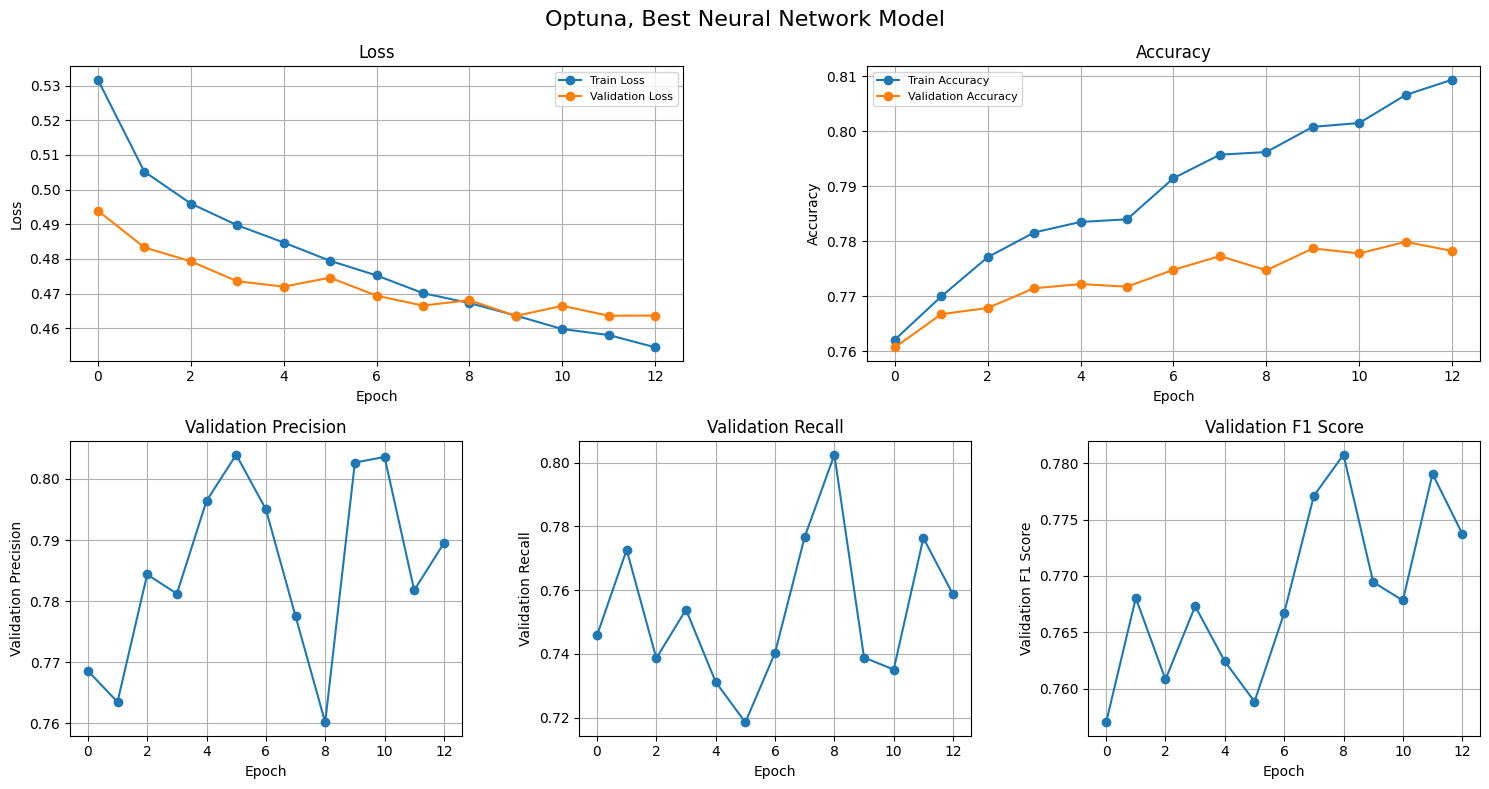

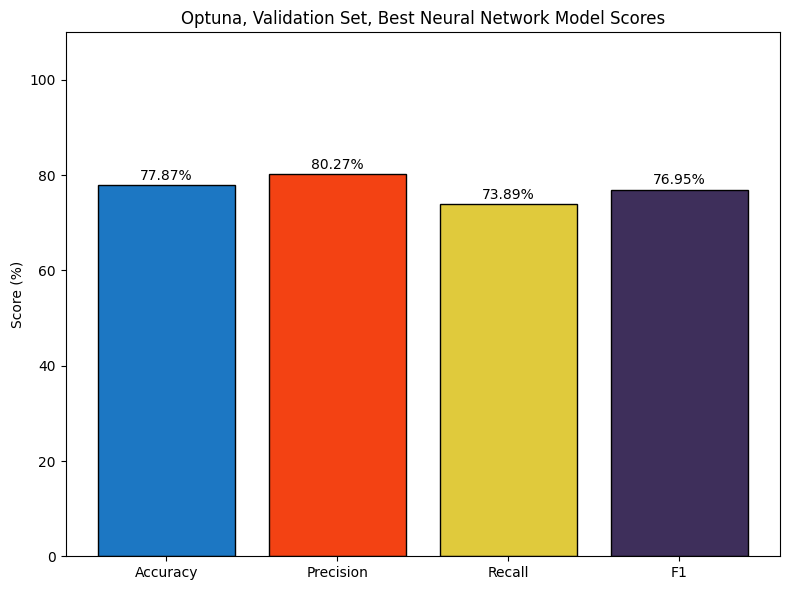

In [89]:
plot_epochs_scores(best_results, "Optuna, Best Neural Network Model")
plot_best_scores(best_results, "Optuna, Validation Set, Best Neural Network Model Scores")

### Rebuilding the best optuna Neural Network model to calculate the ROC curve and confusion matrix as well as to predict the test set

In [124]:
best_params = study.best_trial.params

best_model = NeuralNet(
    D_in=X_train_tensor.shape[1],
    hidden_sizes=best_nn_conf['hidden_sizes'],
    D_out=1,
    activations=[
        best_params[f'activation_{i}'] for i in range(len(best_nn_conf['hidden_sizes']))
    ],
    dropout=best_params['dropout'],
    enable_batch_norm=True
).to(device)

best_model

NeuralNet(
  (hidden_layers): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)

### Generate predictions, probabilities, and true labels for validation set evaluation

In [125]:
best_model.load_state_dict(torch.load("optuna_model.pth"))

best_model.eval()
with torch.no_grad():
    y_val_logits = best_model(X_val_tensor.to(device))
    y_val_probs = torch.sigmoid(y_val_logits)
    y_val_preds = (y_val_probs >= 0.5).long()

y_val_preds = y_val_preds.cpu().numpy().flatten()
y_probab = y_val_probs.cpu().numpy().flatten()
y_val_true = y_val_tensor.cpu().numpy().flatten()

### ROC curve and confusion matrix plotting using the best optuna neural network model result

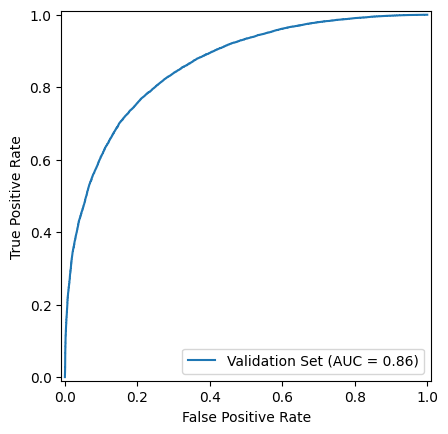

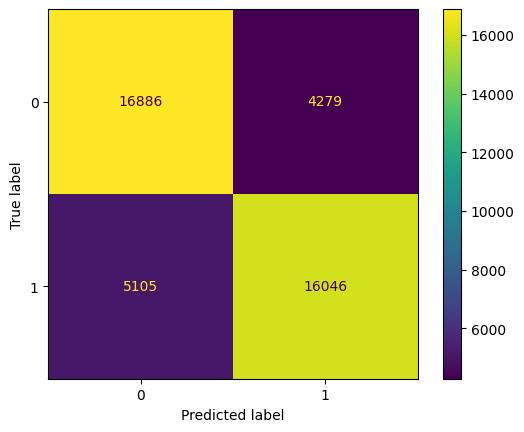

In [126]:
plot_roc_curve(*calc_roc_curve(y_val_true, y_probab), "Validation Set")
plot_confusion_matrix(calc_confusion_matrix(y_val_true, y_val_preds))

### Predict test set using the final optimized model

In [127]:
best_model.eval()

with torch.no_grad():
    y_test_probs = torch.sigmoid(best_model(X_test_tensor.to(device)))
    y_test_preds = (y_test_probs >= 0.5).long()

### Storing the label predictions among with the tweet IDs in a CSV file

In [128]:
pd.DataFrame({
    'ID': df_test['ID'],
    'Label': y_test_preds.cpu().numpy().flatten()
}).to_csv('submission.csv', index=False)